In [4]:
import sys 
from sqlalchemy import create_engine, text

import numpy as np
import sys 
sys.path.append('C:/Users/Data/Documents/lazo_fernando/target_script_01/funciones')
from funciones import *
from variables_inicio import *
from funciones_spark import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.4.0.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.4.0.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()


In [6]:
query = f"""
    select 
        DISTINCT 
        a.CODDOC as vendor_lead_code,
		a.producto,
		a.LINEA_SAE,
		a.TEA,
		a.PROPENSION,
        DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1)) as mes,
		DATEDIFF(
					MONTH,
					DATEADD(DAY, 1, EOMONTH(b.FECHA_ENVIO, -1)),
					DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1))
				) as diferencia
    FROM DANTALION.dbo.Base_Maestra_Cencosud_PPFF a 
    left join DANTALION.dbo.Base_Maestra_Cencosud_PPFF b
    on a.CODDOC=b.CODDOC and a.producto=b.producto
    WHERE a.CODDOC IS NOT NULL
    and a.fecha_envio >='2026-01-01'
	and DATEDIFF(
					MONTH,
					DATEADD(DAY, 1, EOMONTH(b.FECHA_ENVIO, -1)),
					DATEADD(DAY, 1, EOMONTH(a.FECHA_ENVIO, -1))
				) <= 3

"""
df_base=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)

In [7]:
window_spec = Window.partitionBy('producto',"mes","vendor_lead_code").orderBy(F.col('vendor_lead_code').asc_nulls_last())
df_base = df_base.withColumn("ref1_vici", row_number().over(window_spec))
df_base = df_base.filter(F.col('ref1_vici')==1).drop('ref1_vici')    
# df_base.groupBy('mes') \
#     .count() \
#     .orderBy('mes') \
#     .show(30)


In [4]:
print([row['TEA' ] for row in df_base.select('TEA').distinct().collect()])


['0.1255', '0.55', '0.32', '0.22900000', '0.59900000', '0.349', '0.299', '0.60', '0.279', '0.569', '0.24900000', '0.57', '0.25', '0.169', '0.30', '0', '0.419', '0.794', '0.41900000', '0.00000000', '0.09900000', '0.27900000', '0.21', '0.15', '0.79400000', '0.35', '0.39', '0.8791', '0.42', '0.71', '0.79', '0.16900000', '0.89', '0.399', '0.53', '0.14900000', '0.459', '0.52900000', '0.10', '0.33900000', '0.389', '0.65900000', '0.52', '0.54900000', '0.189', '0.40', '0.62', '0.38900000', '0.37', '0.50', '0.499', '0.439', '0.39900000', '0.599', '0.31900000', '0.47900000', '0.34', '0.66', '0.48', '0.61900000', '0.659', '0.709', '0.149', '0.209', '0.56900000', '0.34900000', '0.70900000', '0.28', '0.229', '0.249', '0.23', '0.479', '0.319', '0.29900000', '0.45900000', '0.8364', '0.17', '0.369', '0.339', '0.519', '0.099', '0.36900000', '0.549', '0.51900000', '0.46', '0.619', '0.20900000', '0.44', '0.49900000', '0.25900000', '0.529', '0.43900000', '0.259', '109.83', '1.0186', None]


In [ ]:
['0.1255', '0.55', '0.32', '0.22900000', '0.59900000', '0.349', '0.299', '0.60', '0.279', '0.569', '0.24900000', '0.57', '0.25', '0.169', '0.30', '0', '0.419', '0.794', '0.41900000', '0.00000000', '0.09900000', '0.27900000', '0.21', '0.15', '0.79400000', '0.35', '0.39', '0.8791', '0.42', '0.71', '0.79', '0.16900000', '0.89', '0.399', '0.53', '0.14900000', '0.459', '0.52900000', '0.10', '0.33900000', '0.389', '0.65900000', '0.52', '0.54900000', '0.189', '0.40', '0.62', '0.38900000', '0.37', '0.50', '0.499', '0.439', '0.39900000', '0.599', '0.31900000', '0.47900000', '0.34', '0.66', '0.48', '0.61900000', '0.659', '0.709', '0.149', '0.209', '0.56900000', '0.34900000', '0.70900000', '0.28', '0.229', '0.249', '0.23', '0.479', '0.319', '0.29900000', '0.45900000', '0.8364', '0.17', '0.369', '0.339', '0.519', '0.099', '0.36900000', '0.549', '0.51900000', '0.46', '0.619', '0.20900000', '0.44', '0.49900000', '0.25900000', '0.529', '0.43900000', '0.259', '109.83', '1.0186', None]

In [12]:
print([row['producto' ] for row in df_resumen.select('producto').distinct().collect()])


['Reenganche EC', 'AER', 'AEC', 'EC Cliente', 'CD']


In [8]:
df_base = df_base.withColumn(
    "RANGO_linea_sae",
    F.when(F.col("LINEA_SAE") < 5000, "01. [0 - 5000>")
     .when(F.col("LINEA_SAE") < 10000, "02. [5000 - 10000>")
     .when(F.col("LINEA_SAE") < 15000, "03. [10000 - 15000>")
     .when(F.col("LINEA_SAE") < 20000, "04. [15000 - 20000>")
     .when(F.col("LINEA_SAE") < 30000, "05. [20000 - 30000>")
     .otherwise("06. [30000>")
)

In [9]:

df_base = df_base.withColumn(
    "RANGO_TASA",
    F.when(F.col("TEA").isNull(), "Sin tasa")
     .when(F.col("TEA") < 0.10, "01. < 10%")
     .when(F.col("TEA") < 0.20, "02. 10% - 20%")
     .when(F.col("TEA") < 0.30, "03. 20% - 30%")
     .when(F.col("TEA") < 0.40, "04. 30% - 40%")
     .when(F.col("TEA") < 0.50, "05. 40% - 50%")
     .when(F.col("TEA") < 0.60, "06. 50% - 60%")
     .when(F.col("TEA") < 0.70, "07. 60% - 70%")
     .when(F.col("TEA") < 0.80, "08. 70% - 80%")
     .when(F.col("TEA") <= 1.00, "09. 80% - 100%")
     .otherwise("10. > 100%")
)

In [10]:
df_base=df_base.withColumn('diferencia',when(F.col('diferencia').between(1,3),F.col('diferencia')).otherwise(F.lit('0')))


In [10]:
df_base.show(2)

+----------------+--------+---------+------+----------+----------+----------+------------------+--------------+
|vendor_lead_code|producto|LINEA_SAE|   TEA|PROPENSION|       mes|diferencia|   RANGO_linea_sae|    RANGO_TASA|
+----------------+--------+---------+------+----------+----------+----------+------------------+--------------+
|        00201859|     AEC|     6898|0.8791|      NULL|2026-01-01|         0|02. [5000 - 10000>|09. 80% - 100%|
|        00236629|     AEC|     2800|0.8791|      NULL|2026-01-01|         0|    01. [0 - 5000>|09. 80% - 100%|
+----------------+--------+---------+------+----------+----------+----------+------------------+--------------+
only showing top 2 rows


In [ ]:

df_resumen = (
    df_base
    .groupBy('producto',"mes",'PROPENSION', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("mes", "diferencia")
)

# df_resumen.show(100, False)


In [11]:
from pyspark.sql import functions as F

df_resumen = (
    df_base
    .groupBy('producto',"mes",'PROPENSION', "diferencia")
    .agg(
        F.count("vendor_lead_code").alias("cantidad")
    )
    .orderBy("mes", "diferencia")
)

df_resumen_1 = (
    df_base
    .groupBy('producto',"mes",'PROPENSION', "diferencia")
    .agg(
        F.count("TEA").alias("tea_count"),
        F.sum("TEA").alias("tea_sum")
    )
    .orderBy("mes", "TEA")
)
df_resumen_2 = (
    df_base
    .groupBy('producto',"mes",'PROPENSION', "diferencia")
    .agg(
        F.count("LINEA_SAE").alias("linea_sae_count"),
        F.sum("LINEA_SAE").alias("linea_sae_sum")
    )
    .orderBy("mes", "TEA")
)

df_resumen=df_resumen.join(df_resumen_1,['producto',"mes",'PROPENSION', "diferencia"],'left')
df_resumen=df_resumen.join(df_resumen_2,['producto',"mes",'PROPENSION', "diferencia"],'left')


df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

{"ts": "2026-09-01 16:38:14.655", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TEA` cannot be resolved. Did you mean one of the following? [`mes`, `tea_sum`, `producto`, `PROPENSION`, `tea_count`]. SQLSTATE: 42703", "context": {"file": "line 19 in cell [12]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o265.sort.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TEA` cannot be resolved. Did you mean one of the following? [`mes`, `tea_sum`, `producto`, `PROPENSION`, `tea_count`]. SQLSTATE: 42703;\n'Sort [mes#32 ASC NULLS FIRST, 'TEA ASC NULLS FIRST], true\n+- Aggregate [producto#28, mes#32, PROPENSION#31, diferencia#56L], [producto#28, mes#32, PROPENSION#31, diferencia#56L, count(

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `TEA` cannot be resolved. Did you mean one of the following? [`mes`, `tea_sum`, `producto`, `PROPENSION`, `tea_count`]. SQLSTATE: 42703;
'Sort [mes#32 ASC NULLS FIRST, 'TEA ASC NULLS FIRST], true
+- Aggregate [producto#28, mes#32, PROPENSION#31, diferencia#56L], [producto#28, mes#32, PROPENSION#31, diferencia#56L, count(TEA#30) AS tea_count#96L, sum(cast(TEA#30 as double)) AS tea_sum#97]
   +- Project [vendor_lead_code#27, producto#28, LINEA_SAE#29, TEA#30, PROPENSION#31, mes#32, CASE WHEN ((diferencia#33 >= 1) AND (diferencia#33 <= 3)) THEN cast(diferencia#33 as bigint) ELSE cast(0 as bigint) END AS diferencia#56L, RANGO_linea_sae#54, RANGO_TASA#55]
      +- Project [vendor_lead_code#27, producto#28, LINEA_SAE#29, TEA#30, PROPENSION#31, mes#32, diferencia#33, RANGO_linea_sae#54, CASE WHEN isnull(TEA#30) THEN Sin tasa WHEN (cast(TEA#30 as double) < 0.1) THEN 01. < 10% WHEN (cast(T

In [12]:
df_base = (
    df_base
    .withColumn(
        "LINEA_SAE",
        F.when(F.col("LINEA_SAE").isNull(), None)
         .otherwise(F.col("LINEA_SAE"))
    )
    .withColumn(
        "TEA",
        F.when(F.col("TEA").isNull(), None)
         .otherwise(F.col("TEA"))
    )
)

In [11]:
from pyspark.sql import functions as F

columnas_grupo = [
    "producto",
    "mes",
    "PROPENSION",
    "diferencia"
]

df_resumen = (
    df_base
    .groupBy(*columnas_grupo)
    .agg(
        # Cantidad general de registros
        F.count("vendor_lead_code").alias("cantidad"),

        # TEA
        F.count("TEA").alias("tea_count"),
        F.sum("TEA").alias("tea_sum"),

        # Línea SAE
        F.count("LINEA_SAE").alias("linea_sae_count"),
        F.sum("LINEA_SAE").alias("linea_sae_sum")
    )
    .withColumn(
        "ref",
        F.add_months(
            F.col("mes"),
            -F.col("diferencia").cast("int")
        )
    )
    .orderBy(
        "producto",
        "mes",
        "PROPENSION",
        "diferencia"
    )
)   

In [12]:
df_resumen = df_resumen.withColumn(
    "ref",
    F.add_months(
        F.col("mes"),
        -F.col("diferencia")
    )
)

In [ ]:
df_filtrado = df_resumen.toPandas()


In [ ]:
df_filtrado.head()

,producto,mes,PROPENSION,diferencia,cantidad,tea_count,tea_sum,linea_sae_count,linea_sae_sum,ref
0,AEC,2026-01-01,None,0,1561,1561,1369.8839,1561,6825965.0,2026-01-01
1,AEC,2026-01-01,None,2,59,59,51.7815,59,283118.0,2025-11-01
2,AER,2026-01-01,None,0,3207,3207,2815.5588,3207,9157917.0,2026-01-01
3,AER,2026-01-01,None,2,113,113,99.2956,113,328102.0,2025-11-01
4,CD,2026-01-01,1,0,285,285,54.3850,285,4641000.0,2026-01-01


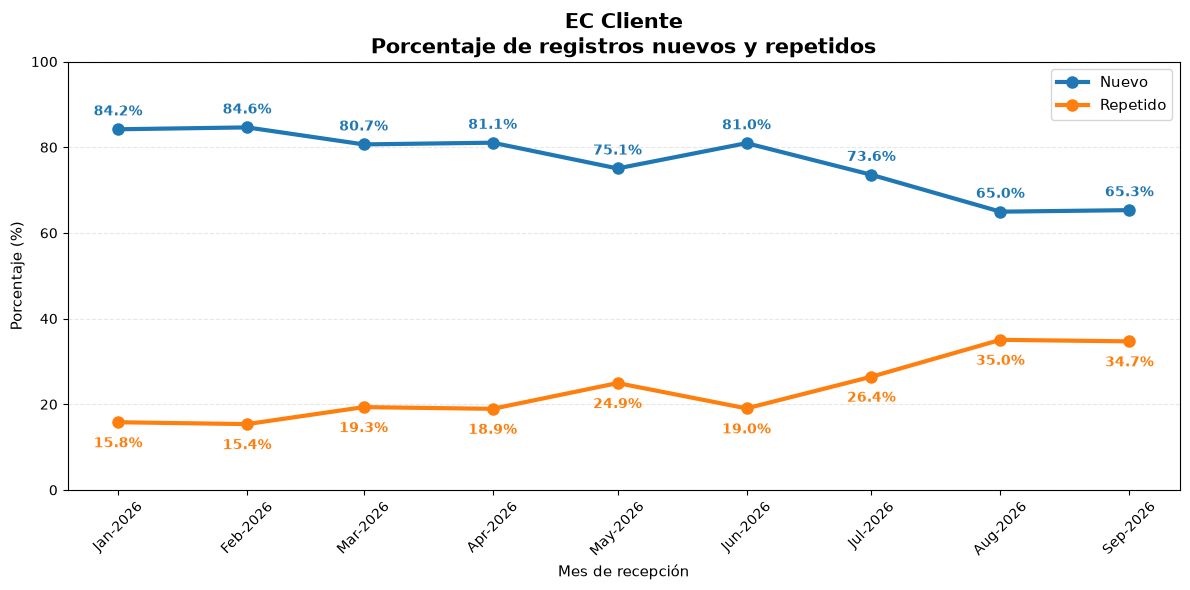

Tipo,Nuevo,Repetido,Total,Porcentaje_nuevo,Porcentaje_repetido
mes,,,,,
2026-01-01,31817,5971,37788,84.20,15.80
2026-02-01,27501,4992,32493,84.64,15.36
2026-03-01,29447,7057,36504,80.67,19.33
2026-04-01,33440,7810,41250,81.07,18.93
2026-05-01,25578,8501,34079,75.06,24.94
2026-06-01,41908,9854,51762,80.96,19.04
2026-07-01,32160,11552,43712,73.57,26.43
2026-08-01,25881,13960,39841,64.96,35.04
2026-09-01,17619,9355,26974,65.32,34.68


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PRODUCTO A ANALIZAR
# ============================================================
producto_seleccionado = "EC Cliente"   # Cambiar por AEC, AER, CD, etc.

# ============================================================
# FILTRAR PRODUCTO
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Asegurar tipos
df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])
df_grafico["diferencia"] = pd.to_numeric(df_grafico["diferencia"], errors="coerce")
df_grafico["cantidad"] = pd.to_numeric(df_grafico["cantidad"], errors="coerce").fillna(0)

# ============================================================
# NUEVO O REPETIDO
# ============================================================
df_grafico["Tipo"] = df_grafico["diferencia"].apply(
    lambda x: "Nuevo" if x == 0 else "Repetido"
)

# ============================================================
# RESUMEN MENSUAL
# ============================================================
df_resumen_grafico = (
    df_grafico
    .groupby(["mes", "Tipo"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# En caso de que falte alguna columna
for col in ["Nuevo", "Repetido"]:
    if col not in df_resumen_grafico.columns:
        df_resumen_grafico[col] = 0

df_resumen_grafico["Total"] = (
    df_resumen_grafico["Nuevo"] +
    df_resumen_grafico["Repetido"]
)

df_resumen_grafico["Porcentaje_nuevo"] = (
    df_resumen_grafico["Nuevo"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico["Porcentaje_repetido"] = (
    df_resumen_grafico["Repetido"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico = df_resumen_grafico.sort_index()

# ============================================================
# GRAFICO
# ============================================================
plt.figure(figsize=(12,6))

# Línea azul
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4",
    label="Nuevo"
)

# Línea naranja
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#ff7f0e",
    label="Repetido"
)

# ============================================================
# ETIQUETAS NUEVO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        color="#1f77b4",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# ETIQUETAS REPETIDO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        color="#ff7f0e",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado}\nPorcentaje de registros nuevos y repetidos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Porcentaje (%)", fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.xticks(
    df_resumen_grafico.index,
    [d.strftime("%b-%Y") for d in df_resumen_grafico.index],
    rotation=45
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_resumen_grafico[
        [
            "Nuevo",
            "Repetido",
            "Total",
            "Porcentaje_nuevo",
            "Porcentaje_repetido"
        ]
    ].round(2)
)

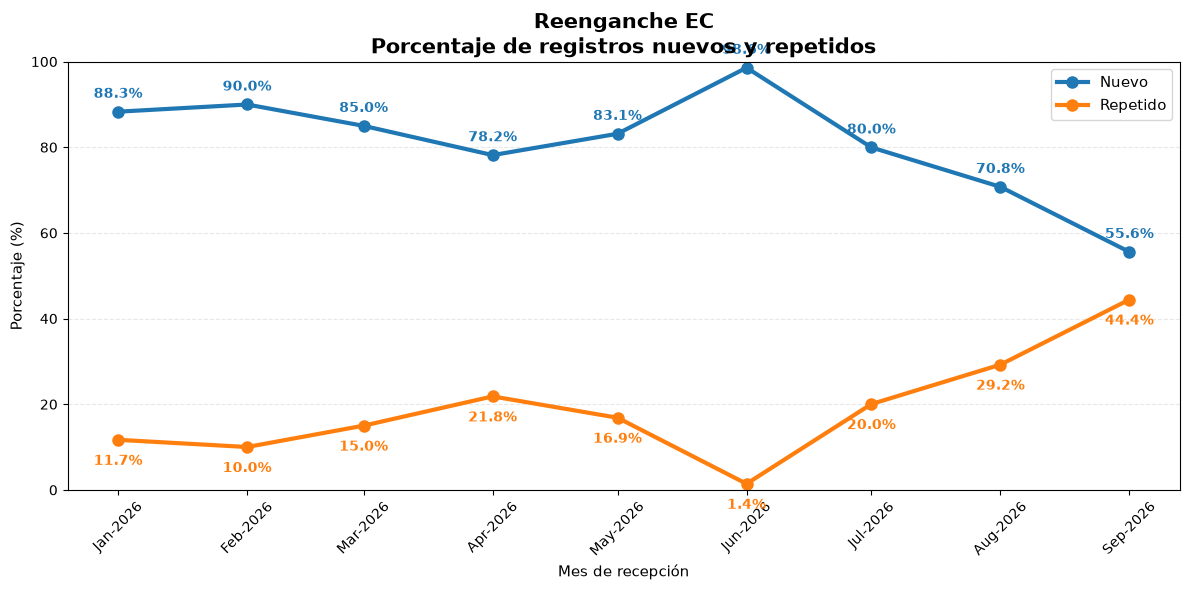

Tipo,Nuevo,Repetido,Total,Porcentaje_nuevo,Porcentaje_repetido
mes,,,,,
2026-01-01,1110,147,1257,88.31,11.69
2026-02-01,1635,182,1817,89.98,10.02
2026-03-01,1501,265,1766,84.99,15.01
2026-04-01,1203,336,1539,78.17,21.83
2026-05-01,1209,245,1454,83.15,16.85
2026-06-01,2071,30,2101,98.57,1.43
2026-07-01,1536,385,1921,79.96,20.04
2026-08-01,2613,1080,3693,70.76,29.24
2026-09-01,1089,871,1960,55.56,44.44


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PRODUCTO A ANALIZAR
# ============================================================
producto_seleccionado = "Reenganche EC"   # Cambiar por AEC, AER, CD, etc.

# ============================================================
# FILTRAR PRODUCTO
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Asegurar tipos
df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])
df_grafico["diferencia"] = pd.to_numeric(df_grafico["diferencia"], errors="coerce")
df_grafico["cantidad"] = pd.to_numeric(df_grafico["cantidad"], errors="coerce").fillna(0)

# ============================================================
# NUEVO O REPETIDO
# ============================================================
df_grafico["Tipo"] = df_grafico["diferencia"].apply(
    lambda x: "Nuevo" if x == 0 else "Repetido"
)

# ============================================================
# RESUMEN MENSUAL
# ============================================================
df_resumen_grafico = (
    df_grafico
    .groupby(["mes", "Tipo"])["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# En caso de que falte alguna columna
for col in ["Nuevo", "Repetido"]:
    if col not in df_resumen_grafico.columns:
        df_resumen_grafico[col] = 0

df_resumen_grafico["Total"] = (
    df_resumen_grafico["Nuevo"] +
    df_resumen_grafico["Repetido"]
)

df_resumen_grafico["Porcentaje_nuevo"] = (
    df_resumen_grafico["Nuevo"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico["Porcentaje_repetido"] = (
    df_resumen_grafico["Repetido"] /
    df_resumen_grafico["Total"] * 100
)

df_resumen_grafico = df_resumen_grafico.sort_index()

# ============================================================
# GRAFICO
# ============================================================
plt.figure(figsize=(12,6))

# Línea azul
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#1f77b4",
    label="Nuevo"
)

# Línea naranja
plt.plot(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"],
    marker="o",
    linewidth=3,
    markersize=8,
    color="#ff7f0e",
    label="Repetido"
)

# ============================================================
# ETIQUETAS NUEVO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_nuevo"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,10),
        textcoords="offset points",
        ha="center",
        color="#1f77b4",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# ETIQUETAS REPETIDO
# ============================================================
for x, y in zip(
    df_resumen_grafico.index,
    df_resumen_grafico["Porcentaje_repetido"]
):
    plt.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0,-18),
        textcoords="offset points",
        ha="center",
        color="#ff7f0e",
        fontsize=10,
        fontweight="bold"
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado}\nPorcentaje de registros nuevos y repetidos",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Porcentaje (%)", fontsize=11)

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.xticks(
    df_resumen_grafico.index,
    [d.strftime("%b-%Y") for d in df_resumen_grafico.index],
    rotation=45
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_resumen_grafico[
        [
            "Nuevo",
            "Repetido",
            "Total",
            "Porcentaje_nuevo",
            "Porcentaje_repetido"
        ]
    ].round(2)
)

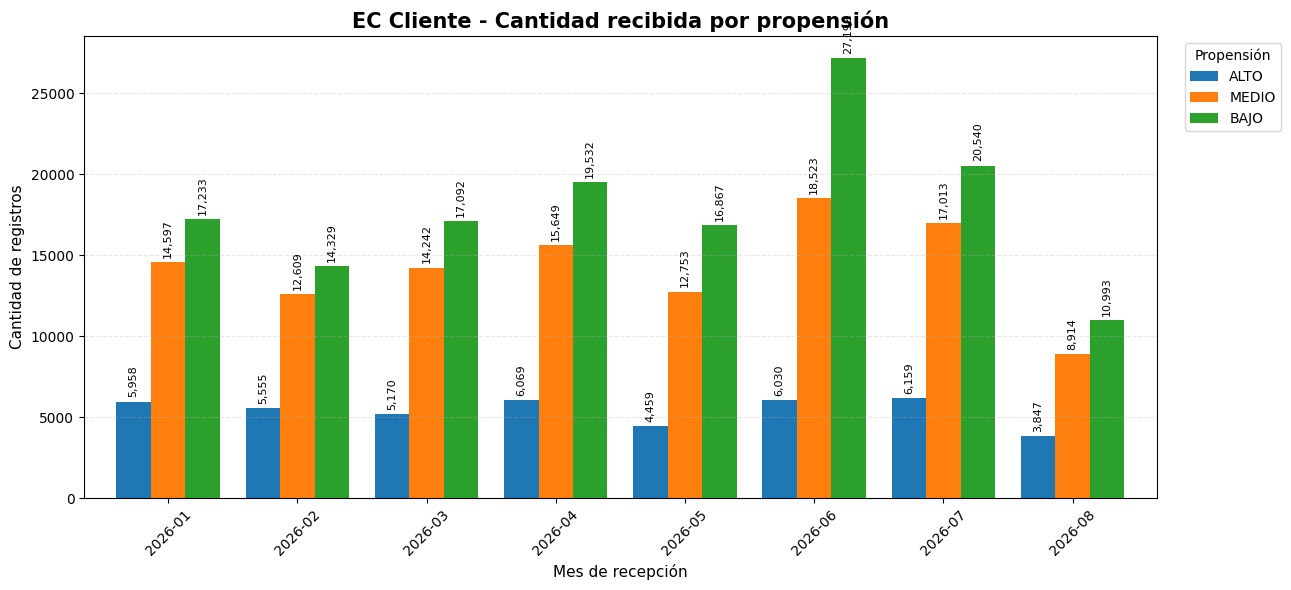

PROPENSION,ALTO,MEDIO,BAJO
mes,,,
2026-01-01,5958,14597,17233
2026-02-01,5555,12609,14329
2026-03-01,5170,14242,17092
2026-04-01,6069,15649,19532
2026-05-01,4459,12753,16867
2026-06-01,6030,18523,27199
2026-07-01,6159,17013,20540
2026-08-01,3847,8914,10993


In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

# Reemplazar propensión nula
df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
)

# ============================================================
# CANTIDAD POR MES Y PROPENSIÓN
# ============================================================
df_propension = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Convertir a formato ancho
df_propension_pivot = (
    df_propension
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Orden deseado de las propensiones
orden_propension = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_propension_pivot.columns
]

# Agregar cualquier otra propensión que exista
otras_columnas = [
    columna
    for columna in df_propension_pivot.columns
    if columna not in columnas_existentes
]

columnas_grafico = columnas_existentes + otras_columnas

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_propension_pivot[columnas_grafico].plot(
    kind="bar",
    figsize=(13, 6),
    width=0.80
)

# Colocar cantidades encima de las barras
for contenedor in ax.containers:
    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad recibida por propensión",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes de recepción", fontsize=11)
plt.ylabel("Cantidad de registros", fontsize=11)

plt.xticks(
    range(len(df_propension_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_propension_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# MOSTRAR TABLA UTILIZADA
# ============================================================
display(
    df_propension_pivot[columnas_grafico]
    .astype(int)
)

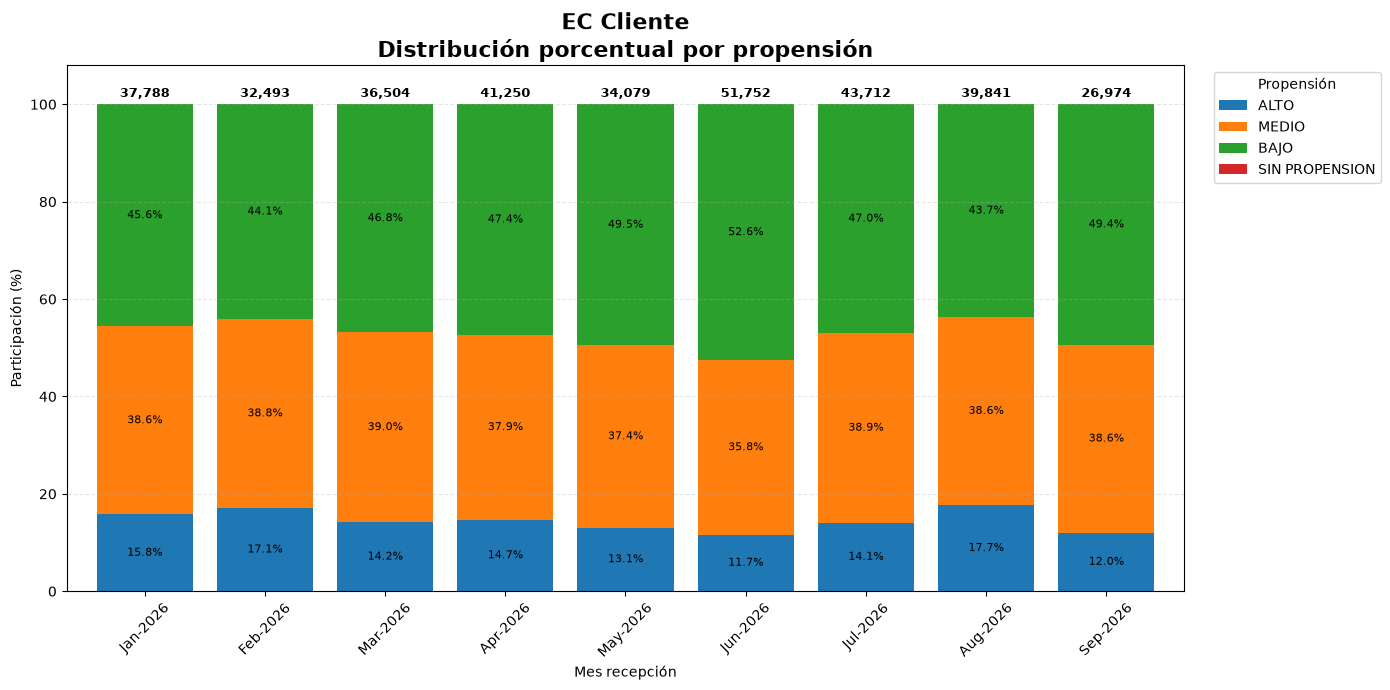

PROPENSION,ALTO,MEDIO,BAJO,SIN PROPENSION,Total Base
mes,,,,,
2026-01-01,15.77%,38.63%,45.60%,0.00%,37788
2026-02-01,17.10%,38.81%,44.10%,0.00%,32493
2026-03-01,14.16%,39.01%,46.82%,0.00%,36504
2026-04-01,14.71%,37.94%,47.35%,0.00%,41250
2026-05-01,13.08%,37.42%,49.49%,0.00%,34079
2026-06-01,11.65%,35.79%,52.56%,0.00%,51752
2026-07-01,14.09%,38.92%,46.99%,0.00%,43712
2026-08-01,17.69%,38.62%,43.68%,0.01%,39841
2026-09-01,12.04%,38.57%,49.39%,0.00%,26974


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"{producto_seleccionado}\nDistribución porcentual por propensión",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

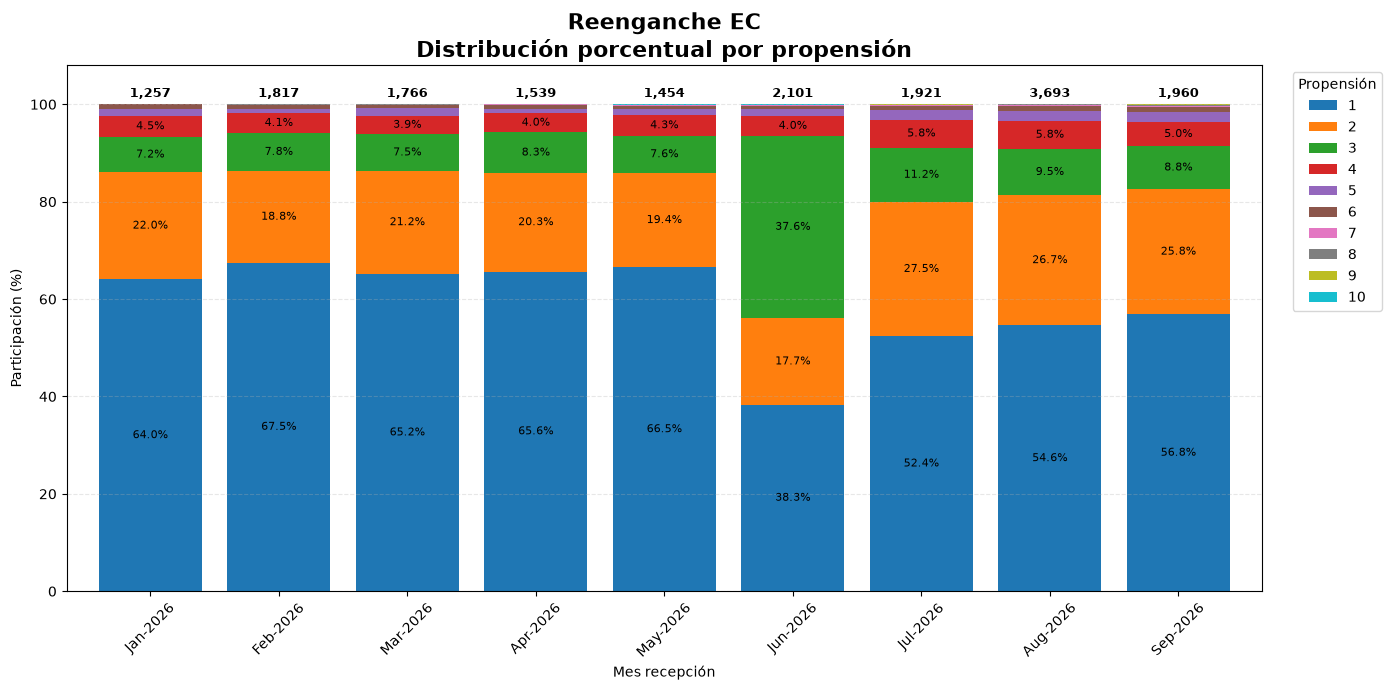

PROPENSION,1,2,3,4,5,6,7,8,9,10,Total Base
mes,,,,,,,,,,,
2026-01-01,64.04%,22.04%,7.16%,4.46%,1.35%,0.95%,0.00%,0.00%,0.00%,0.00%,1257
2026-02-01,67.47%,18.82%,7.82%,4.07%,0.94%,0.77%,0.06%,0.06%,0.00%,0.00%,1817
2026-03-01,65.18%,21.18%,7.47%,3.85%,1.47%,0.68%,0.11%,0.06%,0.00%,0.00%,1766
2026-04-01,65.63%,20.27%,8.32%,3.96%,0.91%,0.84%,0.06%,0.00%,0.00%,0.00%,1539
2026-05-01,66.51%,19.39%,7.63%,4.26%,1.31%,0.55%,0.14%,0.14%,0.00%,0.07%,1454
2026-06-01,38.32%,17.71%,37.55%,3.95%,1.52%,0.67%,0.10%,0.10%,0.05%,0.05%,2101
2026-07-01,52.42%,27.49%,11.19%,5.78%,1.93%,0.78%,0.26%,0.10%,0.05%,0.00%,1921
2026-08-01,54.62%,26.70%,9.53%,5.77%,1.95%,1.03%,0.22%,0.16%,0.03%,0.00%,3693
2026-09-01,56.84%,25.77%,8.78%,5.00%,2.14%,0.97%,0.15%,0.26%,0.10%,0.00%,1960


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"{producto_seleccionado}\nDistribución porcentual por propensión",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

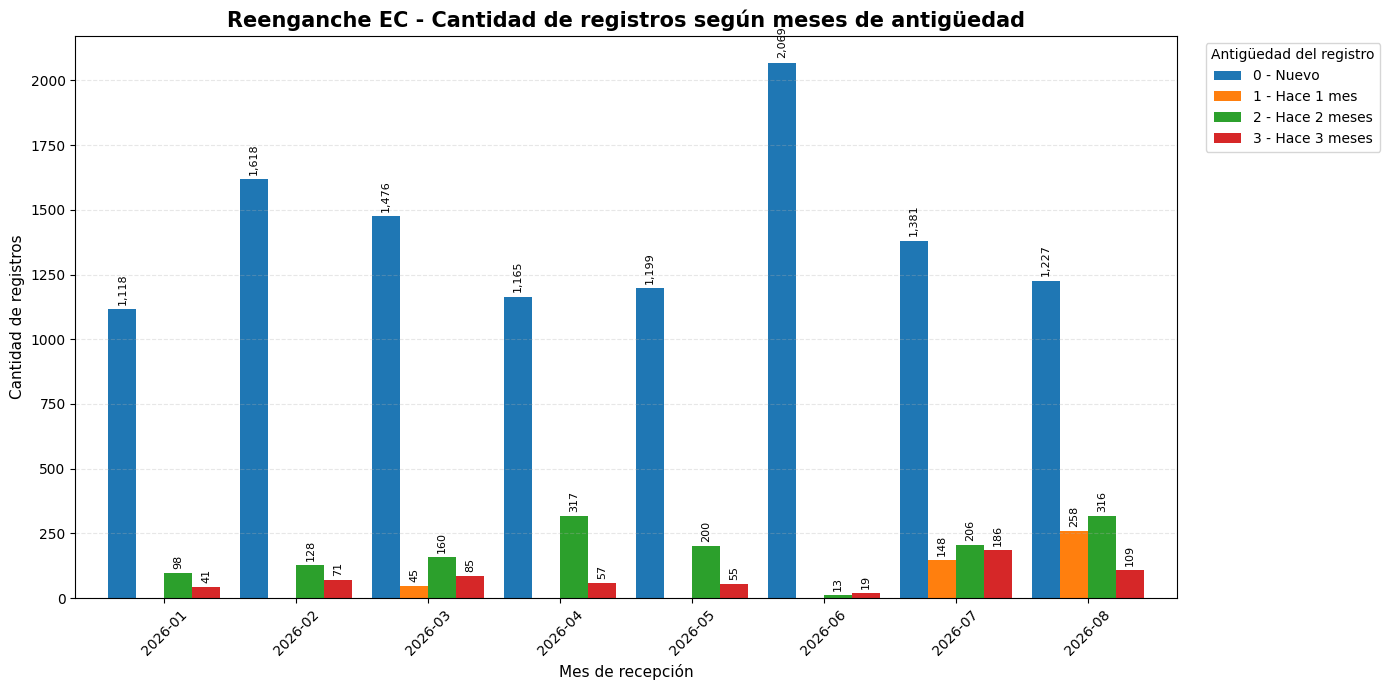

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses
mes,,,,
2026-01-01,1118,0,98,41
2026-02-01,1618,0,128,71
2026-03-01,1476,45,160,85
2026-04-01,1165,0,317,57
2026-05-01,1199,0,200,55
2026-06-01,2069,0,13,19
2026-07-01,1381,148,206,186
2026-08-01,1227,258,316,109


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin diferencia
df_grafico = df_grafico.dropna(subset=["mes", "diferencia"])

# Convertir diferencia a entero
df_grafico["diferencia"] = df_grafico["diferencia"].astype(int)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = df_grafico["diferencia"].apply(
    crear_etiqueta_diferencia
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Crear orden de las categorías según diferencia
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# Convertir a formato ancho
df_diferencia_pivot = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener orden lógico: nuevo, 1 mes, 2 meses, etc.
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_pivot.columns
]

df_diferencia_pivot = df_diferencia_pivot[
    columnas_existentes
]

# ============================================================
# GRÁFICO DE BARRAS AGRUPADAS
# ============================================================
ax = df_diferencia_pivot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.85
)

# Agregar cantidades sobre cada barra
for contenedor in ax.containers:

    etiquetas = [
        f"{barra.get_height():,.0f}"
        if barra.get_height() > 0
        else ""
        for barra in contenedor
    ]

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        padding=3,
        fontsize=8,
        rotation=90
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Cantidad de registros según meses de antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Cantidad de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_pivot.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_pivot.index
    ],
    rotation=45
)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA UTILIZADA
# ============================================================
display(
    df_diferencia_pivot.astype(int)
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

producto = "Reenganche EC"

df = df_filtrado[df_filtrado["producto"] == producto].copy()

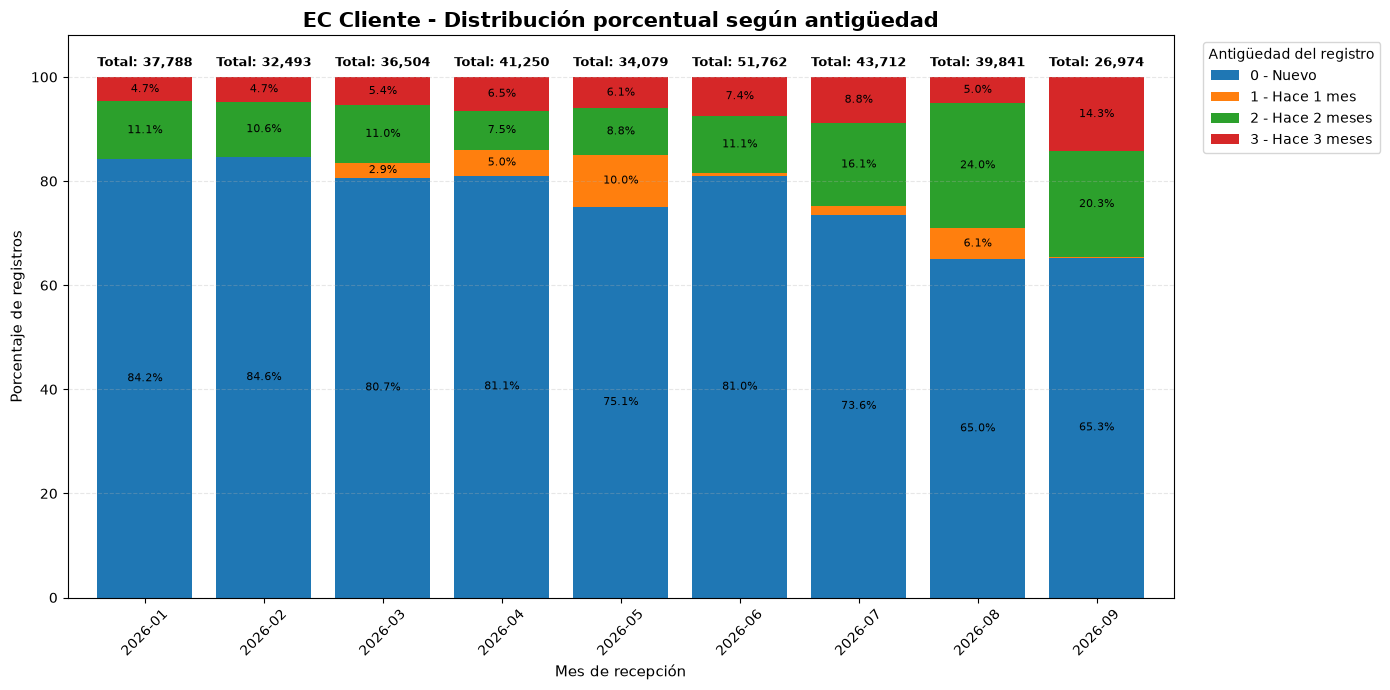

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,84.20%,0.00%,11.10%,4.69%,37788
2026-02-01,84.64%,0.00%,10.63%,4.73%,32493
2026-03-01,80.67%,2.85%,11.04%,5.44%,36504
2026-04-01,81.07%,4.98%,7.48%,6.48%,41250
2026-05-01,75.06%,10.04%,8.85%,6.05%,34079
2026-06-01,80.96%,0.52%,11.11%,7.41%,51762
2026-07-01,73.57%,1.56%,16.08%,8.79%,43712
2026-08-01,64.96%,6.05%,24.01%,4.98%,39841
2026-09-01,65.32%,0.10%,20.28%,14.30%,26974


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
# producto_seleccionado = "Reenganche EC"
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin mes o diferencia
df_grafico = df_grafico.dropna(
    subset=["mes", "diferencia"]
)

# Convertir diferencia a entero
df_grafico["diferencia"] = (
    df_grafico["diferencia"]
    .astype(int)
)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = (
    df_grafico["diferencia"]
    .apply(crear_etiqueta_diferencia)
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Orden correcto de las categorías
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_diferencia_cantidad = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener el orden: nuevo, 1 mes, 2 meses...
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_cantidad.columns
]

df_diferencia_cantidad = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
)

# ============================================================
# TOTAL DE LA BASE POR MES
# ============================================================
df_diferencia_cantidad["Total base"] = (
    df_diferencia_cantidad.sum(axis=1)
)

# ============================================================
# TABLA EN PORCENTAJES
# ============================================================
df_diferencia_porcentaje = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
    .div(
        df_diferencia_cantidad["Total base"],
        axis=0
    )
    * 100
)

# Añadir total de la base como cantidad
df_diferencia_porcentaje["Total base"] = (
    df_diferencia_cantidad["Total base"]
)

# ============================================================
# GRÁFICO DE BARRAS APILADAS AL 100%
# ============================================================
ax = df_diferencia_porcentaje[
    columnas_existentes
].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.80
)

# ============================================================
# ETIQUETAS DE PORCENTAJE DENTRO DE LAS BARRAS
# ============================================================
for contenedor in ax.containers:

    etiquetas = []

    for barra in contenedor:
        valor = barra.get_height()

        if valor >= 2:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# ============================================================
# TOTAL DE LA BASE ENCIMA DE CADA BARRA
# ============================================================
for posicion, total in enumerate(
    df_diferencia_porcentaje["Total base"]
):
    ax.text(
        posicion,
        101.5,
        f"Total: {total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Distribución porcentual según antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Porcentaje de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_porcentaje.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_porcentaje.index
    ],
    rotation=45
)

plt.ylim(0, 108)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA FINAL PARA MOSTRAR
# ============================================================
df_tabla_final = (
    df_diferencia_porcentaje
    .copy()
)

# Dar formato de porcentaje a las columnas de antigüedad
for columna in columnas_existentes:
    df_tabla_final[columna] = (
        df_tabla_final[columna]
        .map(lambda x: f"{x:.2f}%")
    )

# Total base como entero
df_tabla_final["Total base"] = (
    df_tabla_final["Total base"]
    .astype(int)
)

display(df_tabla_final)

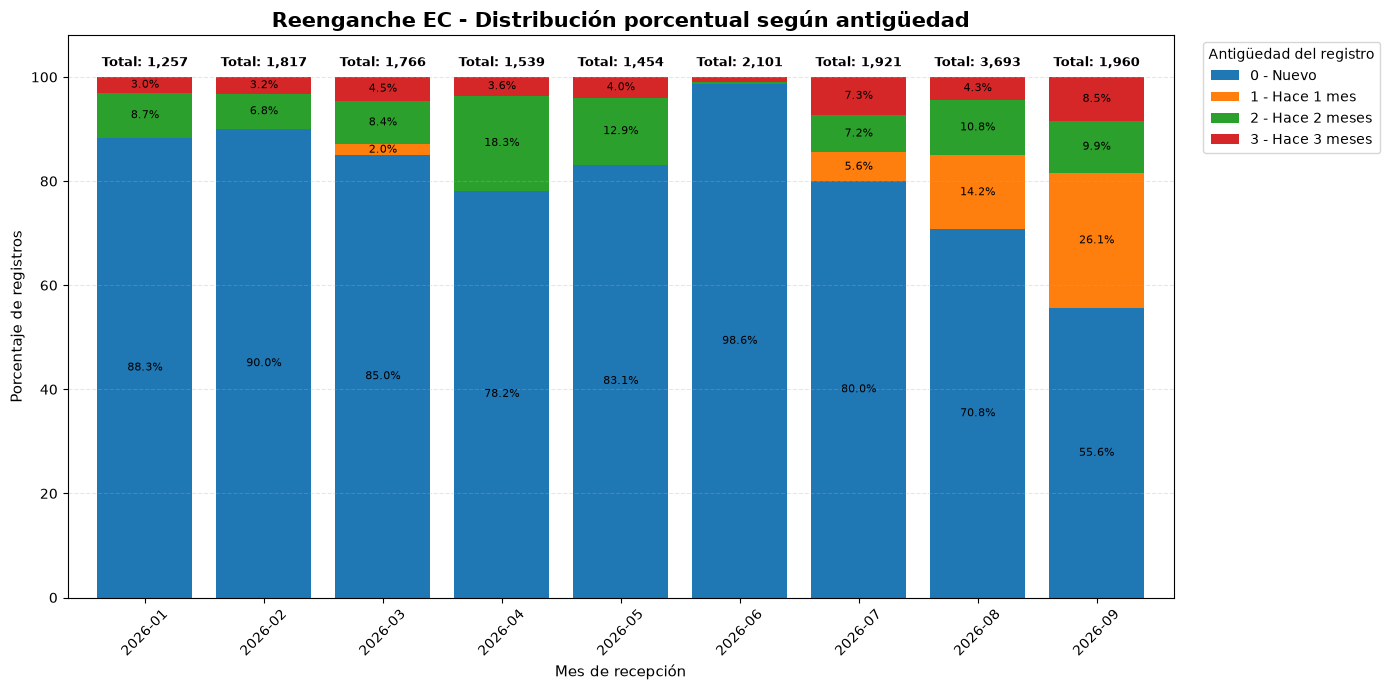

antiguedad,0 - Nuevo,1 - Hace 1 mes,2 - Hace 2 meses,3 - Hace 3 meses,Total base
mes,,,,,
2026-01-01,88.31%,0.00%,8.67%,3.02%,1257
2026-02-01,89.98%,0.00%,6.82%,3.19%,1817
2026-03-01,84.99%,2.04%,8.44%,4.53%,1766
2026-04-01,78.17%,0.00%,18.26%,3.57%,1539
2026-05-01,83.15%,0.00%,12.86%,3.99%,1454
2026-06-01,98.57%,0.00%,0.52%,0.90%,2101
2026-07-01,79.96%,5.57%,7.18%,7.29%,1921
2026-08-01,70.76%,14.16%,10.75%,4.33%,3693
2026-09-01,55.56%,26.07%,9.90%,8.47%,1960


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"
# producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["diferencia"] = pd.to_numeric(
    df_grafico["diferencia"],
    errors="coerce"
)

# Eliminar registros sin mes o diferencia
df_grafico = df_grafico.dropna(
    subset=["mes", "diferencia"]
)

# Convertir diferencia a entero
df_grafico["diferencia"] = (
    df_grafico["diferencia"]
    .astype(int)
)

# ============================================================
# CREAR ETIQUETA DE ANTIGÜEDAD
# ============================================================
def crear_etiqueta_diferencia(valor):
    if valor == 0:
        return "0 - Nuevo"
    elif valor == 1:
        return "1 - Hace 1 mes"
    else:
        return f"{valor} - Hace {valor} meses"


df_grafico["antiguedad"] = (
    df_grafico["diferencia"]
    .apply(crear_etiqueta_diferencia)
)

# ============================================================
# RESUMEN POR MES Y DIFERENCIA
# ============================================================
df_diferencia = (
    df_grafico
    .groupby(
        ["mes", "diferencia", "antiguedad"],
        as_index=False
    )["cantidad"]
    .sum()
)

# Orden correcto de las categorías
orden_antiguedad = (
    df_diferencia[
        ["diferencia", "antiguedad"]
    ]
    .drop_duplicates()
    .sort_values("diferencia")["antiguedad"]
    .tolist()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_diferencia_cantidad = (
    df_diferencia
    .pivot(
        index="mes",
        columns="antiguedad",
        values="cantidad"
    )
    .fillna(0)
    .sort_index()
)

# Mantener el orden: nuevo, 1 mes, 2 meses...
columnas_existentes = [
    columna
    for columna in orden_antiguedad
    if columna in df_diferencia_cantidad.columns
]

df_diferencia_cantidad = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
)

# ============================================================
# TOTAL DE LA BASE POR MES
# ============================================================
df_diferencia_cantidad["Total base"] = (
    df_diferencia_cantidad.sum(axis=1)
)

# ============================================================
# TABLA EN PORCENTAJES
# ============================================================
df_diferencia_porcentaje = (
    df_diferencia_cantidad[
        columnas_existentes
    ]
    .div(
        df_diferencia_cantidad["Total base"],
        axis=0
    )
    * 100
)

# Añadir total de la base como cantidad
df_diferencia_porcentaje["Total base"] = (
    df_diferencia_cantidad["Total base"]
)

# ============================================================
# GRÁFICO DE BARRAS APILADAS AL 100%
# ============================================================
ax = df_diferencia_porcentaje[
    columnas_existentes
].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.80
)

# ============================================================
# ETIQUETAS DE PORCENTAJE DENTRO DE LAS BARRAS
# ============================================================
for contenedor in ax.containers:

    etiquetas = []

    for barra in contenedor:
        valor = barra.get_height()

        if valor >= 2:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# ============================================================
# TOTAL DE LA BASE ENCIMA DE CADA BARRA
# ============================================================
for posicion, total in enumerate(
    df_diferencia_porcentaje["Total base"]
):
    ax.text(
        posicion,
        101.5,
        f"Total: {total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ============================================================
# FORMATO DEL GRÁFICO
# ============================================================
plt.title(
    f"{producto_seleccionado} - Distribución porcentual según antigüedad",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Mes de recepción",
    fontsize=11
)

plt.ylabel(
    "Porcentaje de registros",
    fontsize=11
)

plt.xticks(
    range(len(df_diferencia_porcentaje.index)),
    [
        fecha.strftime("%Y-%m")
        for fecha in df_diferencia_porcentaje.index
    ],
    rotation=45
)

plt.ylim(0, 108)

plt.legend(
    title="Antigüedad del registro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA FINAL PARA MOSTRAR
# ============================================================
df_tabla_final = (
    df_diferencia_porcentaje
    .copy()
)

# Dar formato de porcentaje a las columnas de antigüedad
for columna in columnas_existentes:
    df_tabla_final[columna] = (
        df_tabla_final[columna]
        .map(lambda x: f"{x:.2f}%")
    )

# Total base como entero
df_tabla_final["Total base"] = (
    df_tabla_final["Total base"]
    .astype(int)
)

display(df_tabla_final)

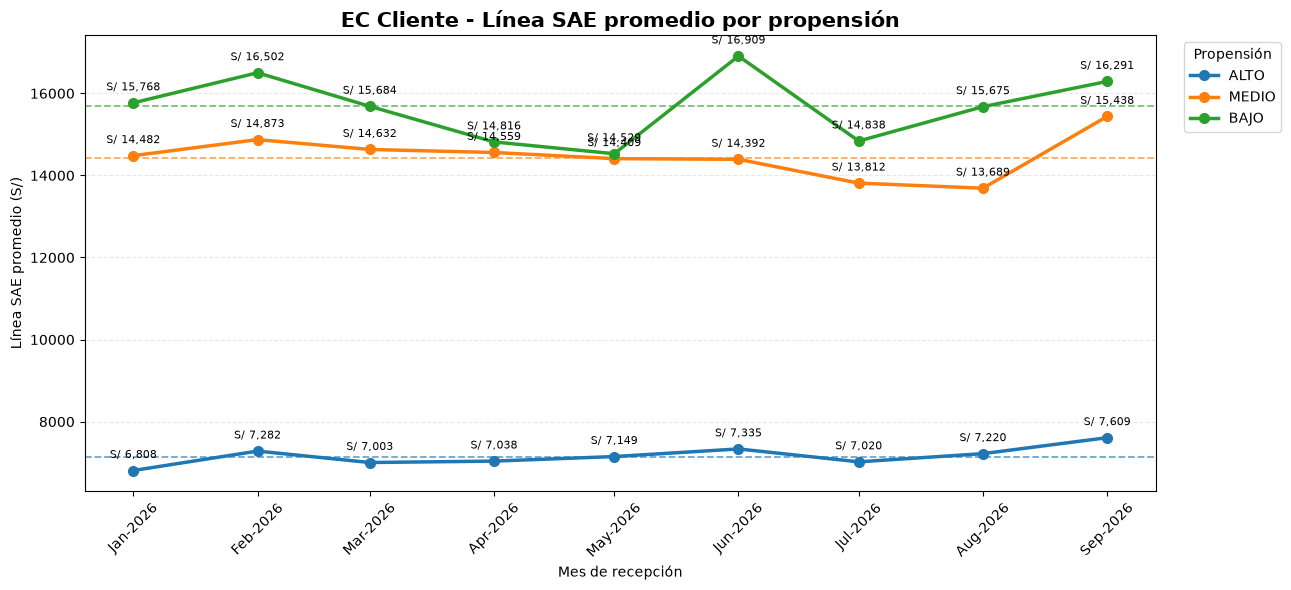

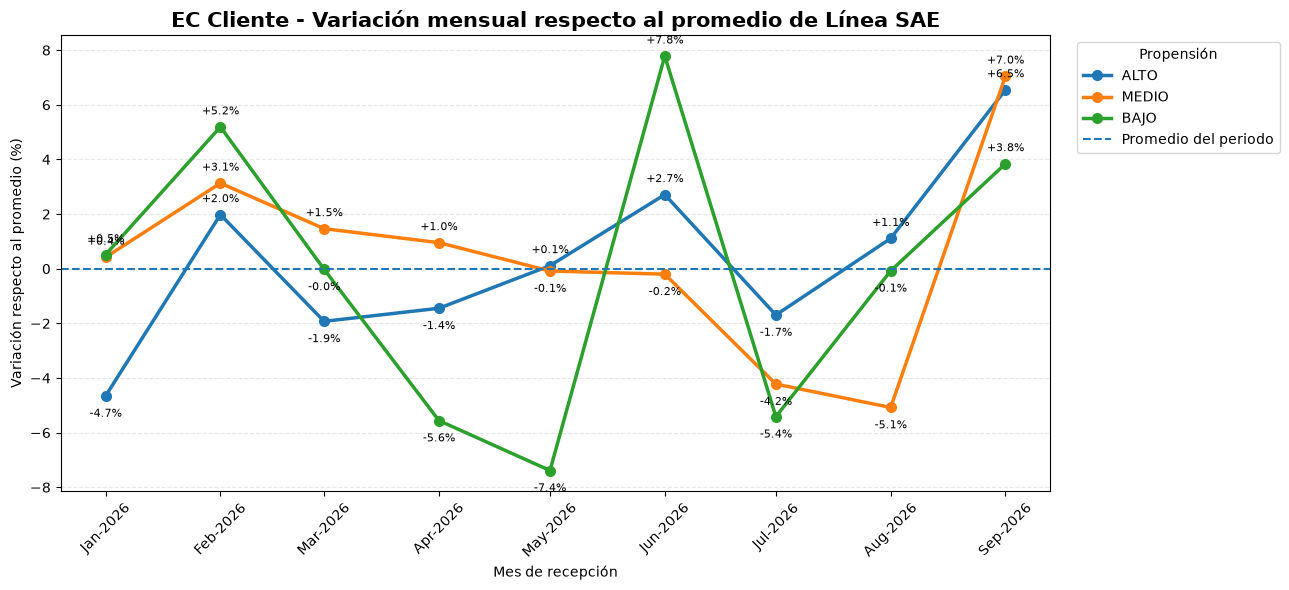

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,ALTO,"S/ 7,140.94","S/ 6,808.43","S/ 7,608.65",S/ 232.68,3.26%,11.21%,Muy estable
1,MEDIO,"S/ 14,421.10","S/ 13,688.63","S/ 15,437.75",S/ 522.71,3.62%,12.13%,Muy estable
2,BAJO,"S/ 15,687.64","S/ 14,528.82","S/ 16,908.71",S/ 817.45,5.21%,15.17%,Estable


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden deseado
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

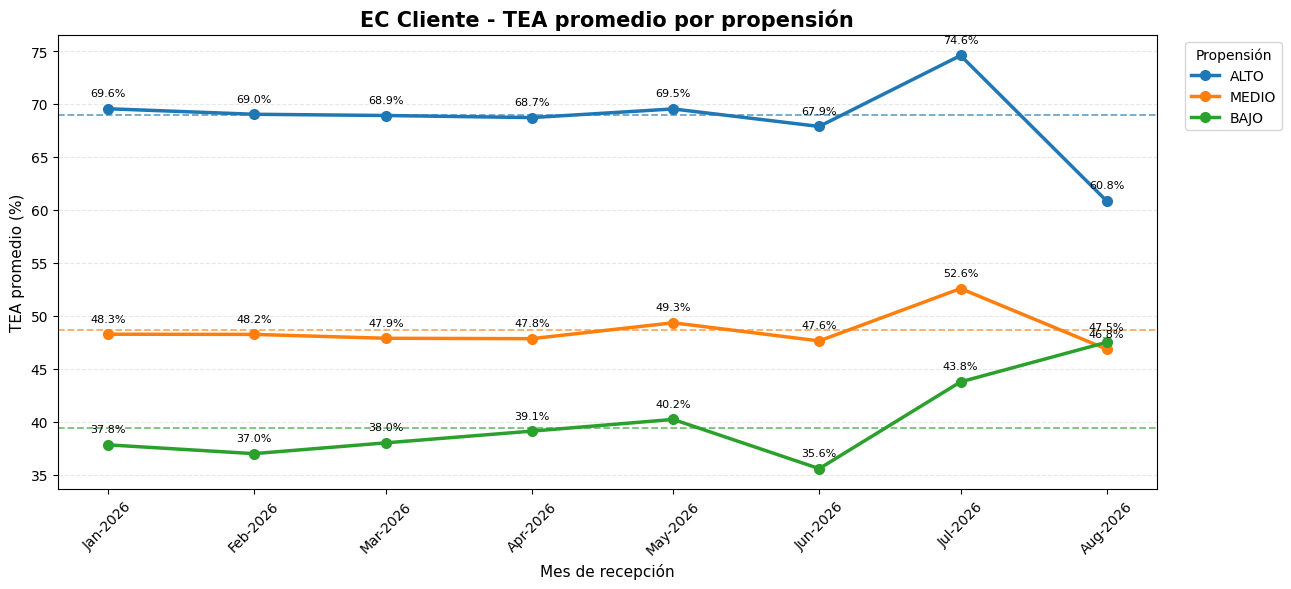

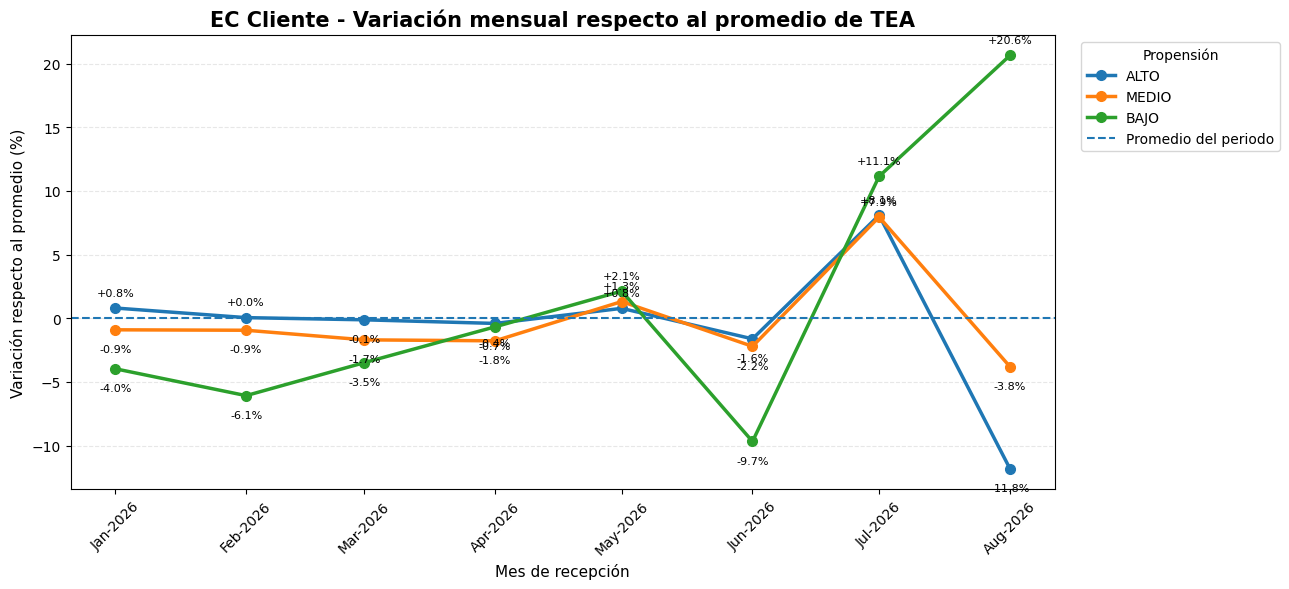

,Propensión,TEA promedio del periodo,TEA mínima mensual,TEA máxima mensual,Desviación estándar,Coeficiente de variación,Rango en puntos porcentuales,Nivel de estabilidad
0,ALTO,69.00%,60.85%,74.58%,3.75%,5.44%,13.73%,Estable
1,MEDIO,48.70%,46.85%,52.57%,1.76%,3.61%,5.72%,Muy estable
2,BAJO,39.37%,35.56%,47.49%,3.94%,10.01%,11.93%,Variable


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# Orden de los segmentos
orden_propension = ["ALTO", "MEDIO", "BAJO"]

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["tea_sum"] = pd.to_numeric(
    df_grafico["tea_sum"],
    errors="coerce"
).fillna(0)

df_grafico["tea_count"] = pd.to_numeric(
    df_grafico["tea_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solo ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin datos válidos de TEA
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["tea_count"] > 0)
].copy()

# ============================================================
# 2. CALCULAR TEA PROMEDIO PONDERADA POR MES Y PROPENSIÓN
# ============================================================
df_tea_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# La TEA original está expresada como decimal:
# 0.6955 = 69.55 %
df_tea_mensual["Promedio_TEA"] = (
    df_tea_mensual["tea_sum"]
    / df_tea_mensual["tea_count"]
    * 100
)

# Formato ancho
df_tea = (
    df_tea_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
    .sort_index()
)

columnas_existentes = [
    propension
    for propension in orden_propension
    if propension in df_tea.columns
]

df_tea = df_tea[columnas_existentes]

# ============================================================
# 3. TEA PROMEDIO PONDERADA DEL PERIODO POR PROPENSIÓN
# ============================================================
df_tea_periodo = (
    df_grafico
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

df_tea_periodo["Promedio_periodo"] = (
    df_tea_periodo["tea_sum"]
    / df_tea_periodo["tea_count"]
    * 100
)

promedios_periodo = (
    df_tea_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN DE LA TEA PROMEDIO POR PROPENSIÓN
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_tea.index,
        df_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Etiquetas mensuales
    for mes, valor in df_tea[propension].dropna().items():
        ax.annotate(
            f"{valor:.1f}%",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Línea punteada: promedio del periodo
    promedio = promedios_periodo.get(propension)

    if promedio is not None and pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - TEA promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "TEA promedio (%)",
    fontsize=11
)

ax.set_xticks(df_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. VARIACIÓN MENSUAL RESPECTO AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion_tea = df_tea.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion_tea[propension] = (
        (
            df_tea[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN DE LA TEA RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion_tea.index,
        df_variacion_tea[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion_tea[propension].dropna().items():

        desplazamiento = 9 if valor >= 0 else -16

        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, desplazamiento),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Referencia central
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de TEA",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mes de recepción",
    fontsize=11
)

ax.set_ylabel(
    "Variación respecto al promedio (%)",
    fontsize=11
)

ax.set_xticks(df_variacion_tea.index)

ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion_tea.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA DE ESTABILIDAD DE LA TEA
# ============================================================
resumen_estabilidad_tea = []

for propension in columnas_existentes:

    valores = df_tea[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_puntos_porcentuales = maximo - minimo

    resumen_estabilidad_tea.append({
        "Propensión": propension,
        "TEA promedio del periodo": promedio,
        "TEA mínima mensual": minimo,
        "TEA máxima mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango en puntos porcentuales": rango_puntos_porcentuales
    })

df_resumen_tea = pd.DataFrame(
    resumen_estabilidad_tea
)

# Clasificación orientativa
df_resumen_tea["Nivel de estabilidad"] = (
    df_resumen_tea["Coeficiente de variación"]
    .apply(
        lambda valor: (
            "Muy estable"
            if valor < 5
            else "Estable"
            if valor < 10
            else "Variable"
        )
    )
)

# ============================================================
# 8. FORMATO DE LA TABLA FINAL
# ============================================================
df_tabla_tea = df_resumen_tea.copy()

for columna in [
    "TEA promedio del periodo",
    "TEA mínima mensual",
    "TEA máxima mensual",
    "Desviación estándar",
    "Coeficiente de variación",
    "Rango en puntos porcentuales"
]:
    df_tabla_tea[columna] = (
        df_tabla_tea[columna]
        .map(lambda valor: f"{valor:.2f}%")
    )

display(df_tabla_tea)

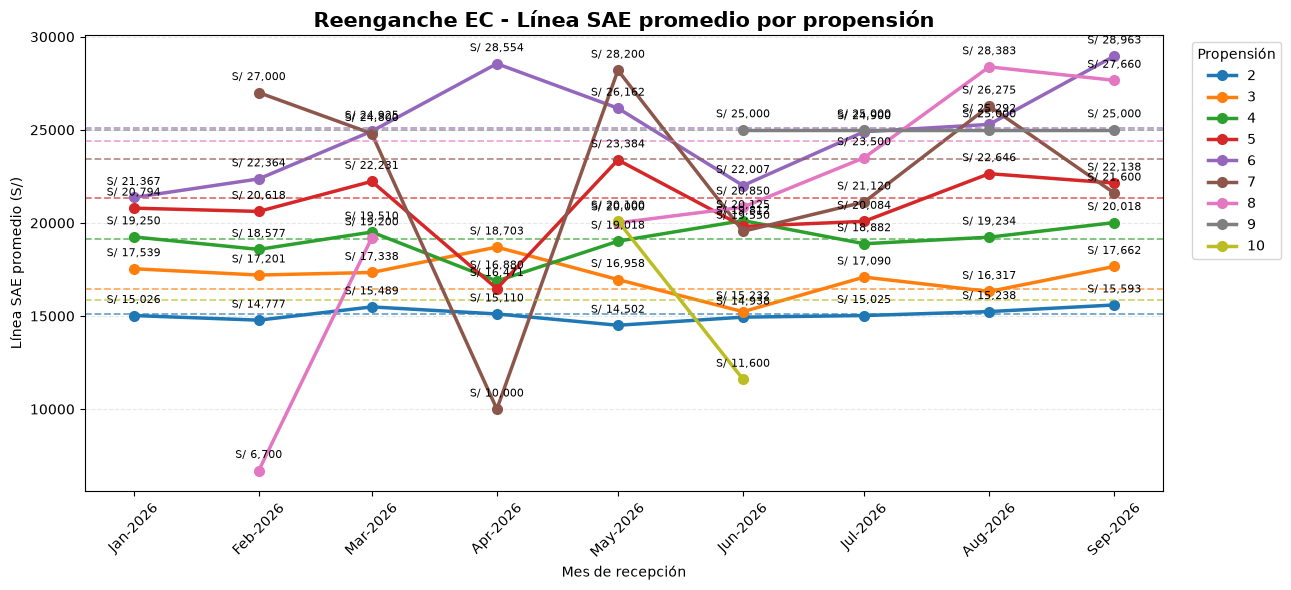

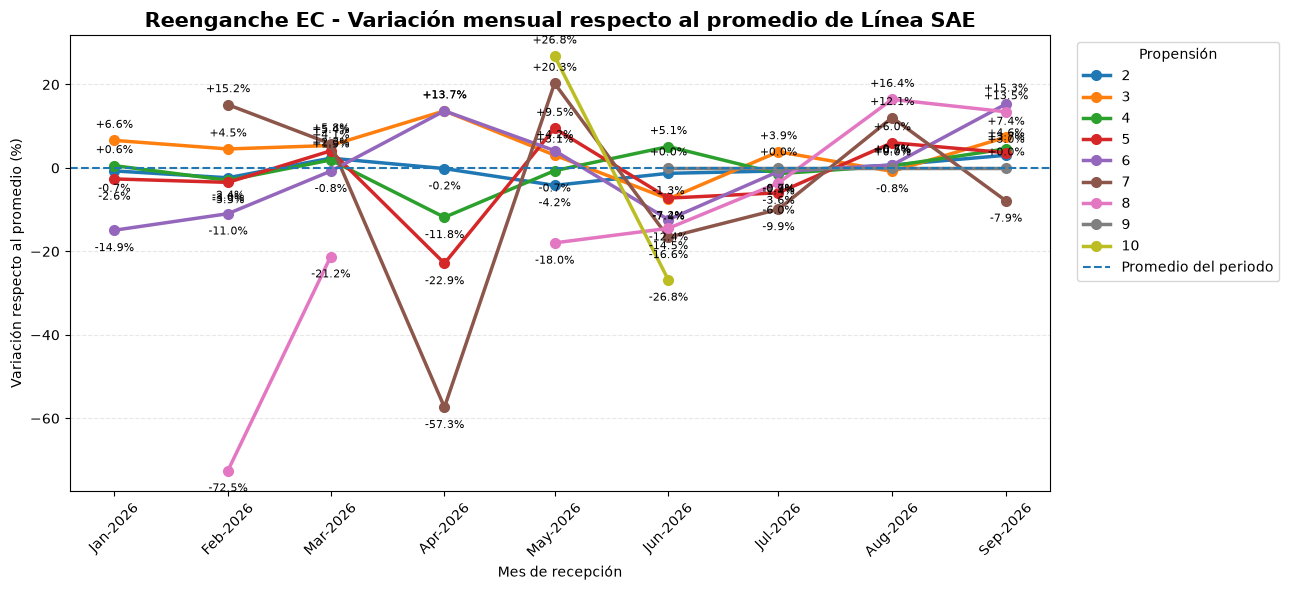

,Propensión,Promedio Línea SAE,Mínimo mensual,Máximo mensual,Desviación estándar,Coeficiente de variación,Rango respecto al promedio,Nivel de estabilidad
0,2,"S/ 15,133.61","S/ 14,502.13","S/ 15,592.67",S/ 336.72,2.23%,7.21%,Muy estable
1,3,"S/ 16,452.23","S/ 15,231.94","S/ 18,703.12",S/ 953.07,5.79%,21.10%,Estable
2,4,"S/ 19,144.31","S/ 16,880.33","S/ 20,125.30",S/ 957.87,5.00%,16.95%,Estable
3,5,"S/ 21,356.16","S/ 16,471.43","S/ 23,384.21","S/ 2,063.81",9.66%,32.37%,Estable
4,6,"S/ 25,117.93","S/ 21,366.67","S/ 28,963.16","S/ 2,712.70",10.80%,30.24%,Variable
5,7,"S/ 23,445.83","S/ 10,000.00","S/ 28,200.00","S/ 5,851.53",24.96%,77.63%,Variable
6,8,"S/ 24,378.95","S/ 6,700.00","S/ 28,383.33","S/ 7,231.88",29.66%,88.94%,Variable
7,9,"S/ 25,000.00","S/ 25,000.00","S/ 25,000.00",S/ 0.00,0.00%,0.00%,Muy estable
8,10,"S/ 15,850.00","S/ 11,600.00","S/ 20,100.00","S/ 6,010.41",37.92%,53.63%,Variable


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"
# producto_seleccionado = "EC Cliente"
# Orden deseado
orden_propension = ["'1'", "2", "3",'4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR DATOS
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(
    df_grafico["mes"],
    errors="coerce"
)

df_grafico["linea_sae_sum"] = pd.to_numeric(
    df_grafico["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_grafico["linea_sae_count"] = pd.to_numeric(
    df_grafico["linea_sae_count"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar únicamente ALTO, MEDIO y BAJO
df_grafico = df_grafico[
    df_grafico["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar registros sin mes o sin observaciones de Línea SAE
df_grafico = df_grafico[
    df_grafico["mes"].notna()
    & (df_grafico["linea_sae_count"] > 0)
].copy()

# ============================================================
# 2. PROMEDIO PONDERADO POR MES Y PROPENSIÓN
# ============================================================
df_mensual = (
    df_grafico
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_mensual["Promedio_linea_sae"] = (
    df_mensual["linea_sae_sum"]
    / df_mensual["linea_sae_count"]
)

# Pasar a formato ancho
df_linea_sae = (
    df_mensual
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
    .sort_index()
)

# Mantener orden de las propensiones
columnas_existentes = [
    columna
    for columna in orden_propension
    if columna in df_linea_sae.columns
]

df_linea_sae = df_linea_sae[columnas_existentes]

# ============================================================
# 3. PROMEDIO PONDERADO DEL PERIODO POR PROPENSIÓN
# ============================================================
df_periodo = (
    df_grafico
    .groupby("PROPENSION", as_index=False)
    .agg(
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum")
    )
)

df_periodo["Promedio_periodo"] = (
    df_periodo["linea_sae_sum"]
    / df_periodo["linea_sae_count"]
)

promedios_periodo = (
    df_periodo
    .set_index("PROPENSION")["Promedio_periodo"]
    .to_dict()
)

# ============================================================
# 4. GRÁFICO 1:
# EVOLUCIÓN MENSUAL DE LA LÍNEA SAE PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    linea, = ax.plot(
        df_linea_sae.index,
        df_linea_sae[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    # Valores mensuales
    for mes, valor in df_linea_sae[propension].dropna().items():
        ax.annotate(
            f"S/ {valor:,.0f}",
            xy=(mes, valor),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    # Promedio del periodo: línea horizontal punteada
    promedio = promedios_periodo.get(propension)

    if pd.notna(promedio):
        ax.axhline(
            y=promedio,
            linestyle="--",
            linewidth=1.3,
            alpha=0.65,
            color=linea.get_color()
        )

ax.set_title(
    f"{producto_seleccionado} - Línea SAE promedio por propensión",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Línea SAE promedio (S/)")

ax.set_xticks(df_linea_sae.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_linea_sae.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. CALCULAR VARIACIÓN FRENTE AL PROMEDIO DEL PERIODO
# ============================================================
df_variacion = df_linea_sae.copy()

for propension in columnas_existentes:

    promedio = promedios_periodo[propension]

    df_variacion[propension] = (
        (
            df_linea_sae[propension]
            / promedio
        ) - 1
    ) * 100

# ============================================================
# 6. GRÁFICO 2:
# VARIACIÓN PORCENTUAL RESPECTO AL PROMEDIO
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

for propension in columnas_existentes:

    ax.plot(
        df_variacion.index,
        df_variacion[propension],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=propension
    )

    for mes, valor in df_variacion[propension].dropna().items():
        ax.annotate(
            f"{valor:+.1f}%",
            xy=(mes, valor),
            xytext=(0, 9 if valor >= 0 else -15),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

# Línea central: promedio del periodo
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    label="Promedio del periodo"
)

ax.set_title(
    f"{producto_seleccionado} - Variación mensual respecto al promedio de Línea SAE",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes de recepción")
ax.set_ylabel("Variación respecto al promedio (%)")

ax.set_xticks(df_variacion.index)
ax.set_xticklabels(
    [
        fecha.strftime("%b-%Y")
        for fecha in df_variacion.index
    ],
    rotation=45
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.legend(
    title="Propensión",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ============================================================
# 7. TABLA RESUMEN DE ESTABILIDAD
# ============================================================
resumen_estabilidad = []

for propension in columnas_existentes:

    valores = df_linea_sae[propension].dropna()

    promedio = promedios_periodo[propension]
    minimo = valores.min()
    maximo = valores.max()
    desviacion = valores.std()

    coeficiente_variacion = (
        desviacion / promedio * 100
        if promedio != 0
        else 0
    )

    rango_porcentual = (
        (maximo - minimo) / promedio * 100
        if promedio != 0
        else 0
    )

    resumen_estabilidad.append({
        "Propensión": propension,
        "Promedio Línea SAE": promedio,
        "Mínimo mensual": minimo,
        "Máximo mensual": maximo,
        "Desviación estándar": desviacion,
        "Coeficiente de variación": coeficiente_variacion,
        "Rango respecto al promedio": rango_porcentual
    })

df_resumen_estabilidad = pd.DataFrame(resumen_estabilidad)

# Clasificación orientativa
df_resumen_estabilidad["Nivel de estabilidad"] = (
    df_resumen_estabilidad["Coeficiente de variación"]
    .apply(
        lambda x: (
            "Muy estable" if x < 5
            else "Estable" if x < 10
            else "Variable"
        )
    )
)

# Dar formato para mostrar
df_tabla_final = df_resumen_estabilidad.copy()

for columna in [
    "Promedio Línea SAE",
    "Mínimo mensual",
    "Máximo mensual",
    "Desviación estándar"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"S/ {x:,.2f}"
    )

for columna in [
    "Coeficiente de variación",
    "Rango respecto al promedio"
]:
    df_tabla_final[columna] = df_tabla_final[columna].map(
        lambda x: f"{x:.2f}%"
    )

display(df_tabla_final)

In [28]:
import pandas as pd
import numpy as np

df_analisis = df_filtrado[
    df_filtrado["producto"] == "EC Cliente"
].copy()

# ============================================================
# 1. LIMPIEZA
# ============================================================

df_analisis["mes"] = pd.to_datetime(
    df_analisis["mes"],
    errors="coerce"
)

df_analisis["PROPENSION"] = (
    df_analisis["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_analisis["linea_sae_sum"] = pd.to_numeric(
    df_analisis["linea_sae_sum"],
    errors="coerce"
)

df_analisis["linea_sae_count"] = pd.to_numeric(
    df_analisis["linea_sae_count"],
    errors="coerce"
)

df_analisis = df_analisis[
    df_analisis["PROPENSION"].isin(["ALTO", "MEDIO", "BAJO"])
    & (df_analisis["linea_sae_count"] > 0)
].copy()


# ============================================================
# 2. LINEA SAE PROMEDIO
# ============================================================

df_analisis["LINEA_SAE_PROMEDIO"] = (
    df_analisis["linea_sae_sum"]
    / df_analisis["linea_sae_count"]
)


# ============================================================
# 3. CREAR RANGOS DE LINEA
#    Puedes cambiar estos cortes según negocio
# ============================================================

bins = [
    0,
    5000,
    10000,
    15000,
    20000,
    np.inf
]

labels = [
    "01. Hasta S/ 5K",
    "02. S/ 5K - 10K",
    "03. S/ 10K - 15K",
    "04. S/ 15K - 20K",
    "05. Más de S/ 20K"
]

df_analisis["RANGO_LINEA"] = pd.cut(
    df_analisis["LINEA_SAE_PROMEDIO"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)


# ============================================================
# 4. MATRIZ PROPENSION x RANGO DE LINEA
# ============================================================

tabla = pd.crosstab(
    df_analisis["PROPENSION"],
    df_analisis["RANGO_LINEA"],
    values=df_analisis["linea_sae_count"],
    aggfunc="sum"
).fillna(0)

tabla = tabla.reindex(
    ["ALTO", "MEDIO", "BAJO"]
)

display(tabla)

RANGO_LINEA,01. Hasta S/ 5K,02. S/ 5K - 10K,03. S/ 10K - 15K,04. S/ 15K - 20K,05. Más de S/ 20K
PROPENSION,,,,,
ALTO,0,49683,0,12,0
MEDIO,0,0,111307,19868,1
BAJO,0,0,53543,109974,0


In [29]:
import pandas as pd

# ============================================================
# ANÁLISIS MENSUAL: PROPENSIÓN + LÍNEA SAE
# ============================================================

producto_seleccionado = "EC Cliente"

df_mes_propension = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# ------------------------------------------------------------
# 1. LIMPIEZA
# ------------------------------------------------------------

df_mes_propension["mes"] = pd.to_datetime(
    df_mes_propension["mes"],
    errors="coerce"
)

df_mes_propension["PROPENSION"] = (
    df_mes_propension["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_mes_propension["linea_sae_sum"] = pd.to_numeric(
    df_mes_propension["linea_sae_sum"],
    errors="coerce"
).fillna(0)

df_mes_propension["linea_sae_count"] = pd.to_numeric(
    df_mes_propension["linea_sae_count"],
    errors="coerce"
).fillna(0)

# Solo las 3 propensiones
df_mes_propension = df_mes_propension[
    df_mes_propension["PROPENSION"].isin(
        ["ALTO", "MEDIO", "BAJO"]
    )
].copy()


# ------------------------------------------------------------
# 2. AGRUPAR POR MES + PROPENSIÓN
# ------------------------------------------------------------

tabla_mensual = (
    df_mes_propension
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        CLIENTES=("linea_sae_count", "sum"),
        LINEA_SAE_TOTAL=("linea_sae_sum", "sum")
    )
)


# ------------------------------------------------------------
# 3. LÍNEA SAE PROMEDIO
# ------------------------------------------------------------

tabla_mensual["LINEA_SAE_PROMEDIO"] = (
    tabla_mensual["LINEA_SAE_TOTAL"]
    / tabla_mensual["CLIENTES"]
)


# ------------------------------------------------------------
# 4. PARTICIPACIÓN DE CADA PROPENSIÓN EN EL MES
# ------------------------------------------------------------

tabla_mensual["TOTAL_MES"] = (
    tabla_mensual
    .groupby("mes")["CLIENTES"]
    .transform("sum")
)

tabla_mensual["PARTICIPACION"] = (
    tabla_mensual["CLIENTES"]
    / tabla_mensual["TOTAL_MES"]
    * 100
)


# ------------------------------------------------------------
# 5. ORDENAR
# ------------------------------------------------------------

orden_propension = ["ALTO", "MEDIO", "BAJO"]

tabla_mensual["PROPENSION"] = pd.Categorical(
    tabla_mensual["PROPENSION"],
    categories=orden_propension,
    ordered=True
)

tabla_mensual = tabla_mensual.sort_values(
    ["mes", "PROPENSION"]
)


# ------------------------------------------------------------
# 6. FORMATO PARA MOSTRAR
# ------------------------------------------------------------

tabla_mostrar = tabla_mensual[
    [
        "mes",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
].copy()

tabla_mostrar["MES"] = (
    tabla_mostrar["mes"]
    .dt.strftime("%Y-%m")
)

tabla_mostrar["PARTICIPACION"] = (
    tabla_mostrar["PARTICIPACION"]
    .map(lambda x: f"{x:.1f}%")
)

tabla_mostrar["LINEA_SAE_PROMEDIO"] = (
    tabla_mostrar["LINEA_SAE_PROMEDIO"]
    .map(lambda x: f"S/ {x:,.0f}")
)

tabla_mostrar = tabla_mostrar[
    [
        "MES",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
]

display(tabla_mostrar)

,MES,PROPENSION,CLIENTES,PARTICIPACION,LINEA_SAE_PROMEDIO
0,2026-01,ALTO,5958,15.8%,"S/ 6,808"
2,2026-01,MEDIO,14597,38.6%,"S/ 14,482"
1,2026-01,BAJO,17233,45.6%,"S/ 15,768"
3,2026-02,ALTO,5555,17.1%,"S/ 7,282"
5,2026-02,MEDIO,12609,38.8%,"S/ 14,873"
4,2026-02,BAJO,14329,44.1%,"S/ 16,502"
6,2026-03,ALTO,5170,14.2%,"S/ 7,003"
8,2026-03,MEDIO,14242,39.0%,"S/ 14,632"
7,2026-03,BAJO,17092,46.8%,"S/ 15,684"
9,2026-04,ALTO,6069,14.7%,"S/ 7,038"


In [30]:
# ============================================================
# COMPARACIÓN AGOSTO VS SEPTIEMBRE
# ============================================================

comparacion = tabla_mensual[
    tabla_mensual["mes"].dt.to_period("M").isin(
        [
            pd.Period("2026-08"),
            pd.Period("2026-09")
        ]
    )
].copy()

comparacion["MES"] = (
    comparacion["mes"]
    .dt.strftime("%Y-%m")
)

comparacion = comparacion[
    [
        "MES",
        "PROPENSION",
        "CLIENTES",
        "PARTICIPACION",
        "LINEA_SAE_PROMEDIO"
    ]
]

display(comparacion)

,MES,PROPENSION,CLIENTES,PARTICIPACION,LINEA_SAE_PROMEDIO
21,2026-08,ALTO,7047,17.690029,7220.051086
23,2026-08,MEDIO,15387,38.625866,13688.633262
22,2026-08,BAJO,17402,43.684105,15675.278704
24,2026-09,ALTO,3248,12.041225,7608.651478
26,2026-09,MEDIO,10403,38.566768,15437.748726
25,2026-09,BAJO,13323,49.392007,16290.625235


In [ ]:
df_filtrado = df_resumen.toPandas()

ruta_archivo = os.path.join(ruta_csv, 'cenvo_repitencia.xlsx')

df_filtrado.to_excel(ruta_archivo, index=False)


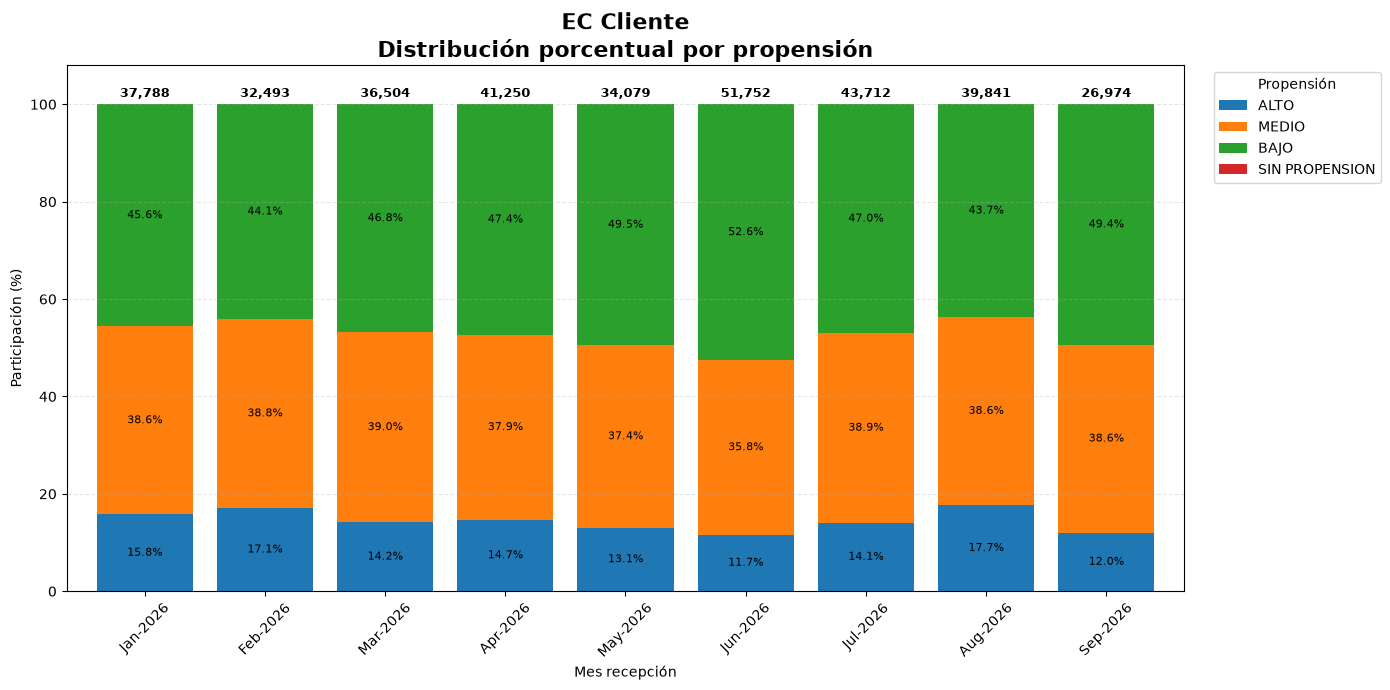

PROPENSION,ALTO,MEDIO,BAJO,SIN PROPENSION,Total Base
mes,,,,,
2026-01-01,15.77%,38.63%,45.60%,0.00%,37788
2026-02-01,17.10%,38.81%,44.10%,0.00%,32493
2026-03-01,14.16%,39.01%,46.82%,0.00%,36504
2026-04-01,14.71%,37.94%,47.35%,0.00%,41250
2026-05-01,13.08%,37.42%,49.49%,0.00%,34079
2026-06-01,11.65%,35.79%,52.56%,0.00%,51752
2026-07-01,14.09%,38.92%,46.99%,0.00%,43712
2026-08-01,17.69%,38.62%,43.68%,0.01%,39841
2026-09-01,12.04%,38.57%,49.39%,0.00%,26974


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "EC Cliente"

# ============================================================
# FILTRAR
# ============================================================
df_grafico = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_grafico["mes"] = pd.to_datetime(df_grafico["mes"])

df_grafico["cantidad"] = pd.to_numeric(
    df_grafico["cantidad"],
    errors="coerce"
).fillna(0)

df_grafico["PROPENSION"] = (
    df_grafico["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# TABLA DE CANTIDADES
# ============================================================
df_prop = (
    df_grafico
    .groupby(
        ["mes","PROPENSION"]
    )["cantidad"]
    .sum()
    .unstack(fill_value=0)
)

# Orden de las columnas
orden = [
    "ALTO",
    "MEDIO",
    "BAJO",
    "SIN PROPENSION"
]

columnas = [
    c
    for c in orden
    if c in df_prop.columns
]

df_prop = df_prop[columnas]

# ============================================================
# TOTAL BASE
# ============================================================
df_prop["Total Base"] = df_prop.sum(axis=1)

# ============================================================
# PORCENTAJES
# ============================================================
df_prop_pct = (
    df_prop[columnas]
    .div(df_prop["Total Base"],axis=0)
    *100
)

# Guardar total
df_prop_pct["Total Base"] = df_prop["Total Base"]

# ============================================================
# GRAFICO APILADO
# ============================================================
ax = df_prop_pct[columnas].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    width=0.80
)

# Etiquetas
for contenedor in ax.containers:

    etiquetas=[]

    for barra in contenedor:

        valor=barra.get_height()

        if valor>=3:
            etiquetas.append(f"{valor:.1f}%")
        else:
            etiquetas.append("")

    ax.bar_label(
        contenedor,
        labels=etiquetas,
        label_type="center",
        fontsize=8
    )

# Total encima
for x,total in enumerate(df_prop_pct["Total Base"]):

    ax.text(
        x,
        101.5,
        f"{int(total):,}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title(
    f"{producto_seleccionado}\nDistribución porcentual por propensión",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Participación (%)")
plt.xlabel("Mes recepción")

plt.xticks(
    range(len(df_prop_pct.index)),
    [
        fecha.strftime("%b-%Y")
        for fecha in df_prop_pct.index
    ],
    rotation=45
)

plt.ylim(0,108)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=.3
)

plt.legend(
    title="Propensión",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ============================================================
# TABLA
# ============================================================

tabla=df_prop_pct.copy()

for c in columnas:
    tabla[c]=tabla[c].map(lambda x:f"{x:.2f}%")

tabla["Total Base"]=tabla["Total Base"].astype(int)

display(tabla)

In [61]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# Orden de presentación
orden_propension = ['1','2','3','4','5','6','7','8','9','10']

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

# Convertir mes
df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

# Convertir columnas numéricas
columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Limpiar propensión
df_tabla["PROPENSION"] = (
    df_tabla["PROPENSION"]
    .fillna("SIN PROPENSION")
    .astype(str)
    .str.strip()
    .str.upper()
)

# Conservar solamente ALTO, MEDIO y BAJO
df_tabla = df_tabla[
    df_tabla["PROPENSION"].isin(orden_propension)
].copy()

# Eliminar filas sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR POR MES Y PROPENSIÓN
# ============================================================
df_resumen = (
    df_tabla
    .groupby(
        ["mes", "PROPENSION"],
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen["Promedio_linea_sae"] = np.where(
    df_resumen["linea_sae_count"] > 0,
    df_resumen["linea_sae_sum"]
    / df_resumen["linea_sae_count"],
    np.nan
)

# La TEA está almacenada como decimal:
# 0.6955 equivale a 69.55 %
df_resumen["Promedio_TEA"] = np.where(
    df_resumen["tea_count"] > 0,
    (
        df_resumen["tea_sum"]
        / df_resumen["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. TOTAL DE LA BASE POR MES
# ============================================================
df_total_mes = (
    df_resumen
    .groupby("mes", as_index=False)["cantidad"]
    .sum()
    .rename(
        columns={
            "cantidad": "Total Base"
        }
    )
)

df_resumen = df_resumen.merge(
    df_total_mes,
    on="mes",
    how="left"
)

# Participación de cada propensión dentro del mes
df_resumen["Participacion"] = np.where(
    df_resumen["Total Base"] > 0,
    (
        df_resumen["cantidad"]
        / df_resumen["Total Base"]
    ) * 100,
    0
)

# ============================================================
# 5. CREAR TABLAS PIVOT
# ============================================================

# Participación porcentual
tabla_participacion = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Participacion"
    )
)

# Línea SAE promedio
tabla_linea_sae = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_linea_sae"
    )
)

# TEA promedio
tabla_tea = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="Promedio_TEA"
    )
)

# Cantidad por propensión
tabla_cantidad = (
    df_resumen
    .pivot(
        index="mes",
        columns="PROPENSION",
        values="cantidad"
    )
)

# Asegurar que las columnas estén en orden
for propension in orden_propension:

    if propension not in tabla_participacion.columns:
        tabla_participacion[propension] = 0

    if propension not in tabla_linea_sae.columns:
        tabla_linea_sae[propension] = np.nan

    if propension not in tabla_tea.columns:
        tabla_tea[propension] = np.nan

    if propension not in tabla_cantidad.columns:
        tabla_cantidad[propension] = 0

tabla_participacion = tabla_participacion[orden_propension]
tabla_linea_sae = tabla_linea_sae[orden_propension]
tabla_tea = tabla_tea[orden_propension]
tabla_cantidad = tabla_cantidad[orden_propension]

# ============================================================
# 6. ARMAR TABLA FINAL
# ============================================================
df_tabla_final = pd.DataFrame(
    index=tabla_participacion.index
)

# Total mensual
df_tabla_final["Total Base"] = (
    tabla_cantidad.sum(axis=1)
)

# Columnas por propensión
for propension in orden_propension:

    df_tabla_final[
        f"% {propension}"
    ] = tabla_participacion[propension]

    df_tabla_final[
        f"Línea SAE {propension}"
    ] = tabla_linea_sae[propension]

    df_tabla_final[
        f"TEA {propension}"
    ] = tabla_tea[propension]

# ============================================================
# 7. FILA CONSOLIDADA DEL PERIODO
# ============================================================
df_periodo = (
    df_tabla
    .groupby(
        "PROPENSION",
        as_index=False
    )
    .agg(
        cantidad=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
)

total_periodo = df_periodo["cantidad"].sum()

fila_periodo = {
    "Total Base": total_periodo
}

for propension in orden_propension:

    datos = df_periodo[
        df_periodo["PROPENSION"] == propension
    ]

    if not datos.empty:

        cantidad_propension = datos["cantidad"].iloc[0]

        participacion = (
            cantidad_propension / total_periodo * 100
            if total_periodo > 0
            else 0
        )

        promedio_linea = (
            datos["linea_sae_sum"].iloc[0]
            / datos["linea_sae_count"].iloc[0]
            if datos["linea_sae_count"].iloc[0] > 0
            else np.nan
        )

        promedio_tea = (
            datos["tea_sum"].iloc[0]
            / datos["tea_count"].iloc[0]
            * 100
            if datos["tea_count"].iloc[0] > 0
            else np.nan
        )

    else:

        participacion = 0
        promedio_linea = np.nan
        promedio_tea = np.nan

    fila_periodo[f"% {propension}"] = participacion
    fila_periodo[f"Línea SAE {propension}"] = promedio_linea
    fila_periodo[f"TEA {propension}"] = promedio_tea

# Cambiar el índice mensual a texto
df_tabla_final.index = [
    fecha.strftime("%B %Y").capitalize()
    for fecha in df_tabla_final.index
]

# Agregar fila consolidada
df_tabla_final.loc["TOTAL PERIODO"] = fila_periodo

# ============================================================
# 8. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

# Total base como entero con separador de miles
df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

for propension in orden_propension:

    # Participación
    df_tabla_mostrar[f"% {propension}"] = (
        df_tabla_mostrar[f"% {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

    # Línea SAE
    df_tabla_mostrar[f"Línea SAE {propension}"] = (
        df_tabla_mostrar[f"Línea SAE {propension}"]
        .map(
            lambda valor:
            f"S/ {valor:,.2f}"
            if pd.notna(valor)
            else "-"
        )
    )

    # TEA
    df_tabla_mostrar[f"TEA {propension}"] = (
        df_tabla_mostrar[f"TEA {propension}"]
        .map(
            lambda valor:
            f"{valor:.2f}%"
            if pd.notna(valor)
            else "-"
        )
    )

# Nombre del índice
df_tabla_mostrar.index.name = "Mes de recepción"

# ============================================================
# 9. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Total Base,% 1,Línea SAE 1,TEA 1,% 2,Línea SAE 2,TEA 2,% 3,Línea SAE 3,TEA 3,...,TEA 7,% 8,Línea SAE 8,TEA 8,% 9,Línea SAE 9,TEA 9,% 10,Línea SAE 10,TEA 10
Mes de recepción,,,,,,,,,,,,,,,,,,,,,
January 2026,"1,257",64.04%,"S/ 12,911.30",46.19%,22.04%,"S/ 15,025.63",35.57%,7.16%,"S/ 17,538.89",30.77%,...,-,-,-,-,-,-,-,-,-,-
February 2026,"1,817",67.47%,"S/ 13,092.90",46.82%,18.82%,"S/ 14,777.19",35.13%,7.82%,"S/ 17,200.70",32.18%,...,20.90%,0.06%,"S/ 6,700.00",39.90%,-,-,-,-,-,-
March 2026,"1,766",65.18%,"S/ 12,855.87",39.90%,21.18%,"S/ 15,488.50",-,7.47%,"S/ 17,337.88",-,...,-,0.06%,"S/ 19,200.00",-,-,-,-,-,-,-
April 2026,"1,539",65.63%,"S/ 13,165.94",46.09%,20.27%,"S/ 15,110.26",35.83%,8.32%,"S/ 18,703.12",31.32%,...,27.90%,-,-,-,-,-,-,-,-,-
May 2026,"1,454",66.51%,"S/ 13,053.36",47.64%,19.39%,"S/ 14,502.13",37.56%,7.63%,"S/ 16,957.66",31.34%,...,20.90%,0.14%,"S/ 20,000.00",10.45%,-,-,-,0.07%,"S/ 20,100.00",20.90%
June 2026,"2,101",38.32%,"S/ 13,932.92",41.33%,17.71%,"S/ 14,938.44",34.79%,37.55%,"S/ 15,231.94",39.65%,...,27.90%,0.10%,"S/ 20,850.00",27.90%,0.05%,"S/ 25,000.00",20.90%,0.05%,"S/ 11,600.00",20.90%
July 2026,"1,921",52.42%,"S/ 13,614.70",40.68%,27.49%,"S/ 15,025.00",34.11%,11.19%,"S/ 17,090.23",31.55%,...,21.70%,0.10%,"S/ 23,500.00",20.90%,0.05%,"S/ 25,000.00",20.90%,-,-,-
August 2026,"1,509",56.20%,"S/ 12,739.74",43.74%,26.64%,"S/ 15,197.76",34.66%,9.21%,"S/ 16,226.62",30.68%,...,14.45%,-,-,-,-,-,-,-,-,-
TOTAL PERIODO,"13,364",58.51%,"S/ 13,159.24",44.77%,21.62%,"S/ 15,026.79",35.20%,13.06%,"S/ 16,342.38",35.42%,...,21.30%,0.06%,"S/ 19,325.00",22.63%,0.01%,"S/ 25,000.00",20.90%,0.01%,"S/ 15,850.00",20.90%


In [62]:
import pandas as pd
import numpy as np

# ============================================================
# CAMBIAR ÚNICAMENTE EL PRODUCTO
# ============================================================
producto_seleccionado = "Reenganche EC"

# ============================================================
# 1. FILTRAR Y PREPARAR LOS DATOS
# ============================================================
df_tabla = df_filtrado[
    df_filtrado["producto"] == producto_seleccionado
].copy()

df_tabla["mes"] = pd.to_datetime(
    df_tabla["mes"],
    errors="coerce"
)

columnas_numericas = [
    "cantidad",
    "linea_sae_sum",
    "linea_sae_count",
    "tea_sum",
    "tea_count"
]

for columna in columnas_numericas:
    df_tabla[columna] = pd.to_numeric(
        df_tabla[columna],
        errors="coerce"
    ).fillna(0)

# Eliminar registros sin mes
df_tabla = df_tabla.dropna(subset=["mes"])

# ============================================================
# 2. AGRUPAR SOLAMENTE POR MES
# No se considera PROPENSION
# ============================================================
df_resumen_mensual = (
    df_tabla
    .groupby(
        "mes",
        as_index=False
    )
    .agg(
        total_base=("cantidad", "sum"),
        linea_sae_sum=("linea_sae_sum", "sum"),
        linea_sae_count=("linea_sae_count", "sum"),
        tea_sum=("tea_sum", "sum"),
        tea_count=("tea_count", "sum")
    )
    .sort_values("mes")
)

# ============================================================
# 3. CALCULAR PROMEDIOS PONDERADOS
# ============================================================
df_resumen_mensual["Promedio Línea SAE"] = np.where(
    df_resumen_mensual["linea_sae_count"] > 0,
    (
        df_resumen_mensual["linea_sae_sum"]
        / df_resumen_mensual["linea_sae_count"]
    ),
    np.nan
)

# TEA almacenada como decimal:
# 0.50 equivale a 50 %
df_resumen_mensual["Promedio TEA"] = np.where(
    df_resumen_mensual["tea_count"] > 0,
    (
        df_resumen_mensual["tea_sum"]
        / df_resumen_mensual["tea_count"]
    ) * 100,
    np.nan
)

# ============================================================
# 4. SELECCIONAR COLUMNAS FINALES
# ============================================================
df_tabla_final = df_resumen_mensual[
    [
        "mes",
        "total_base",
        "Promedio Línea SAE",
        "Promedio TEA"
    ]
].copy()

df_tabla_final = df_tabla_final.rename(
    columns={
        "mes": "Mes de recepción",
        "total_base": "Total Base"
    }
)

# ============================================================
# 5. FILA TOTAL DEL PERIODO
# ============================================================
total_base_periodo = df_tabla["cantidad"].sum()

total_linea_sum = df_tabla["linea_sae_sum"].sum()
total_linea_count = df_tabla["linea_sae_count"].sum()

total_tea_sum = df_tabla["tea_sum"].sum()
total_tea_count = df_tabla["tea_count"].sum()

promedio_linea_periodo = (
    total_linea_sum / total_linea_count
    if total_linea_count > 0
    else np.nan
)

promedio_tea_periodo = (
    total_tea_sum / total_tea_count * 100
    if total_tea_count > 0
    else np.nan
)

fila_total = pd.DataFrame({
    "Mes de recepción": ["TOTAL PERIODO"],
    "Total Base": [total_base_periodo],
    "Promedio Línea SAE": [promedio_linea_periodo],
    "Promedio TEA": [promedio_tea_periodo]
})

# Convertir meses a texto antes de concatenar
df_tabla_final["Mes de recepción"] = (
    df_tabla_final["Mes de recepción"]
    .dt.strftime("%B %Y")
    .str.capitalize()
)

df_tabla_final = pd.concat(
    [
        df_tabla_final,
        fila_total
    ],
    ignore_index=True
)

# ============================================================
# 6. DAR FORMATO PARA MOSTRAR
# ============================================================
df_tabla_mostrar = df_tabla_final.copy()

df_tabla_mostrar["Total Base"] = (
    df_tabla_mostrar["Total Base"]
    .fillna(0)
    .map(lambda valor: f"{valor:,.0f}")
)

df_tabla_mostrar["Promedio Línea SAE"] = (
    df_tabla_mostrar["Promedio Línea SAE"]
    .map(
        lambda valor:
        f"S/ {valor:,.2f}"
        if pd.notna(valor)
        else "-"
    )
)

df_tabla_mostrar["Promedio TEA"] = (
    df_tabla_mostrar["Promedio TEA"]
    .map(
        lambda valor:
        f"{valor:.2f}%"
        if pd.notna(valor)
        else "-"
    )
)

# ============================================================
# 7. MOSTRAR TABLA
# ============================================================
display(df_tabla_mostrar)

,Mes de recepción,Total Base,Promedio Línea SAE,Promedio TEA
0,January 2026,"1,257","S/ 14,178.28",41.47%
1,February 2026,"1,817","S/ 14,100.28",42.40%
2,March 2026,"1,766","S/ 14,241.79",39.90%
3,April 2026,"1,539","S/ 14,325.86",41.74%
4,May 2026,"1,454","S/ 14,129.09",43.19%
5,June 2026,"2,101","S/ 15,002.86",38.64%
6,July 2026,"1,921","S/ 14,944.14",36.71%
7,August 2026,"1,509","S/ 14,375.28",38.56%
8,TOTAL PERIODO,"13,364","S/ 14,449.68",40.19%
